<a href="https://colab.research.google.com/github/jonasknoll57/Bachelorarbeit_Demand-AD/blob/main/V7_Phase1_DataAudit_Mannheim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Daten-Audit — Mannheim BSS
## Cross-City Transfer Learning zur Anomalie-Erkennung (BA)

**Ziel:** Systematische Exploration der Rohdaten vor der AD-Pipeline.
Identifikation von Datenqualitätsproblemen, Cleaning-Maßnahmen und strukturellen Eigenschaften
die sowohl die Anomalie-Erkennung als auch den späteren Cross-City Transfer beeinflussen.

**Struktur:**
1. Setup & Datenladen
2. City-Level Demand über Zeit — Lücken, Ausreißer, Systemausfälle
3. Stations-Lebenszyklus — Geburt, Tod, ID-Wechsel, Umzüge
4. Datenqualität pro Station — Zero-Inflation, Aktivitätsmuster, Rauschen
5. Geo-Plausibilität — Stationen außerhalb Mannheim?
6. Wetter-Datenlücken & Coverage
7. Poisson vs. Gauß-Verteilung — Labeling-Implikationen
8. Cleaning-Empfehlungen zusammenfassen

In [1]:
# ══════════════════════════════════════════════════════════════
# 0 — Google Drive & Setup
# ══════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/BA_Colab/data.zip" "/content/data.zip"
!unzip -q "/content/data.zip" -d "/content"
!rm "/content/data.zip"
!rm -rf "/content/_MACOSX"

Mounted at /content/drive


In [ ]:
# ══════════════════════════════════════════════════════════════
# 0b — Cleaning: Erstellt /content/data/cleaned/
#
# Maßnahmen (basierend auf Audit-Ergebnissen):
#   [1] geo_information: WKB-Hex → lat/lon dekodieren, 'location' droppen
#   [2] demand/Mannheim: nur station_type='real' behalten
#   [3] demand/Mannheim: Stationen mit max. Datenlücke > 90 Tage entfernen
#   [4] demand/Mannheim: fehlende Tage (Demand-Lücken auf Stadtebene) entfernen
#
# Alles andere (weather, holidays, vacations, station_names, osm)
# bleibt unverändert — wird direkt aus /content/data/ gelesen.
# ══════════════════════════════════════════════════════════════

import os, glob, re
import pandas as pd
import pyarrow.parquet as pq
import pyarrow as pa
from shapely import wkb as shapely_wkb

DATA_BASE    = '/content/data'
CLEANED_BASE = '/content/data/cleaned'
CITY         = 'Mannheim'

# ── Station-Typ Klassifikation (identisch zur Pipeline) ──
def classify_station(name):
    if not isinstance(name, str) or name.strip() == '': return 'unknown'
    n = name.strip()
    if re.search(r'(?i)^recording[_\-\s]', n): return 'recording'
    if re.match(r'(?i)^bike[-_]?\s*\d*', n):   return 'bike'
    if re.search(r'(?i)(virtuell|virtual)', n): return 'virtual'
    if re.fullmatch(r'[\d\s\-_\.#/]+', n):     return 'only_nums'
    return 'real'

station_names_raw = pd.read_parquet(f'{DATA_BASE}/station_names/station_names.parquet')
station_names_raw = station_names_raw.rename(columns={'id': 'station_name_id', 'name': 'station_name'})
station_names_raw['station_type'] = station_names_raw['station_name'].apply(classify_station)
type_lookup = station_names_raw.set_index('station_name_id')['station_type'].to_dict()

print('╔══════════════════════════════════════════════════╗')
print('║  CLEANING — Erstelle /content/data/cleaned/      ║')
print('╚══════════════════════════════════════════════════╝')

# ────────────────────────────────────────────────
# [1] GEO_INFORMATION: WKB → lat/lon
# ────────────────────────────────────────────────
print('\n[1] geo_information: WKB → lat/lon ...')

geo_out_dir = f'{CLEANED_BASE}/geo_information'
os.makedirs(geo_out_dir, exist_ok=True)

geo_raw = pq.read_table(f'{DATA_BASE}/geo_information').to_pandas()
geom = geo_raw['location'].apply(lambda x: shapely_wkb.loads(bytes.fromhex(x)))
geo_raw['latitude']  = geom.apply(lambda g: round(g.y, 6))
geo_raw['longitude'] = geom.apply(lambda g: round(g.x, 6))
geo_clean = geo_raw.drop(columns=['location'])

geo_clean.to_parquet(f'{geo_out_dir}/geo_information.parquet', index=False)
print(f'  ✅ Gespeichert: {len(geo_clean):,} Einträge, Spalten: {list(geo_clean.columns)}')

# ────────────────────────────────────────────────
# [2+3+4] DEMAND / MANNHEIM
# ────────────────────────────────────────────────
print(f'\n[2-4] demand/{CITY}: Laden ...')

files = glob.glob(f'{DATA_BASE}/demand/{CITY}/**/*.parquet', recursive=True)
if not files:
    files = glob.glob(f'{DATA_BASE}/demand/{CITY}/*.parquet')
print(f'  Parquet-Dateien gefunden: {len(files)}')

cols = ['network_name', 'timestamp', 'station_id', 'station_name_id',
        'location_id', 'n_lends', 'n_returns']
demand = pd.concat([pd.read_parquet(f, columns=cols) for f in files], ignore_index=True)
demand['timestamp']    = pd.to_datetime(demand['timestamp'], utc=True)
demand['station_type'] = demand['station_name_id'].map(type_lookup).fillna('unknown')
demand['total_demand'] = demand['n_lends'] + demand['n_returns']
print(f'  Roh: {len(demand):,} Zeilen, {demand["station_id"].nunique()} Stationen')

# [2] Nur real Stationen
before = len(demand)
demand = demand[demand['station_type'] == 'real'].copy()
print(f'\n  [2] Nur real stations: {len(demand):,} Zeilen '
      f'(entfernt: {before - len(demand):,}) | '
      f'{demand["station_id"].nunique()} Stationen')

# [3] Stationen mit max. Datenlücke > 90 Tage entfernen
print(f'\n  [3] Berechne Datenlücken pro Station ...')
demand['date'] = demand['timestamp'].dt.date

def max_gap(dates):
    s = sorted(set(pd.to_datetime(d) for d in dates))
    if len(s) < 2: return 0
    return max((s[i+1] - s[i]).days - 1 for i in range(len(s)-1))

station_gaps = (
    demand.groupby('station_id')['date']
    .apply(max_gap)
    .reset_index()
    .rename(columns={'date': 'max_gap_days'})
)
bad_stations = station_gaps[station_gaps['max_gap_days'] > 90]['station_id'].tolist()
demand = demand[~demand['station_id'].isin(bad_stations)].copy()
print(f'  Stationen mit Lücke > 90d entfernt: {len(bad_stations)} → {bad_stations}')
print(f'  Nach Lücken-Filter: {demand["station_id"].nunique()} Stationen, {len(demand):,} Zeilen')

# [4] Fehlende Tage auf Stadtebene entfernen
print(f'\n  [4] Fehlende Tage auf Stadtebene entfernen ...')
daily_city = demand.groupby('date')['total_demand'].sum().reset_index()
all_dates  = pd.date_range(demand['timestamp'].min().date(),
                           demand['timestamp'].max().date(), freq='D')
existing_dates = set(pd.Timestamp(d) for d in daily_city['date'])
missing_dates  = [d for d in all_dates if d not in existing_dates]

if missing_dates:
    missing_date_set = {d.date() for d in missing_dates}
    demand = demand[~demand['date'].isin(missing_date_set)].copy()
    print(f'  Entfernte Tage: {[str(d.date()) for d in missing_dates]}')
else:
    print('  Keine fehlenden Tage gefunden.')

# station_type Spalte droppen (war nur für Cleaning, nicht in Original)
demand = demand.drop(columns=['station_type', 'total_demand', 'date'])

# Speichern — gleiche Ordnerstruktur wie Original
demand_out_dir = f'{CLEANED_BASE}/demand/{CITY}'
os.makedirs(demand_out_dir, exist_ok=True)
demand.to_parquet(f'{demand_out_dir}/demand_cleaned.parquet', index=False)

print(f'\n  ✅ Gespeichert: {len(demand):,} Zeilen, '
      f'{demand["station_id"].nunique()} Stationen')
print(f'  Pfad: {demand_out_dir}/demand_cleaned.parquet')

# ────────────────────────────────────────────────
# Zusammenfassung
# ────────────────────────────────────────────────
print('\n╔══════════════════════════════════════════════════╗')
print('║  CLEANING ABGESCHLOSSEN                          ║')
print('╚══════════════════════════════════════════════════╝')
print(f'  /content/data/cleaned/')
print(f'  ├── geo_information/geo_information.parquet  (lat/lon dekodiert)')
print(f'  └── demand/{CITY}/demand_cleaned.parquet')
print(f'      ├── nur real stations')
print(f'      ├── {len(bad_stations)} Stationen (Lücke >90d) entfernt')
print(f'      └── fehlende Tage entfernt: {len(missing_dates)}')
print(f'\n  Unverändert aus /content/data/:')
print(f'  weather/, holidays/, vacations/, station_names/, osm/')

In [2]:
# ══════════════════════════════════════════════════════════════
# 1 — Imports & Pfade
# ══════════════════════════════════════════════════════════════
import os, glob, re, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm
import seaborn as sns
from scipy import stats as scipy_stats
from scipy.stats import poisson, norm, kstest

# Plotstil
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'figure.facecolor': 'white'
})
AUDIT_OUTPUT = '/content/data/audit_plots'
os.makedirs(AUDIT_OUTPUT, exist_ok=True)

# Pfade (identisch zu V4)
DEMAND_BASE        = '/content/data/demand'
STATION_NAMES_PATH = '/content/data/station_names/station_names.parquet'
GEO_INFO_PATH      = '/content/data/geo_information/geo_information.parquet'
WEATHER_PATH       = '/content/data/weather/weather.parquet'
HOLIDAYS_PATH      = '/content/data/holidays/holidays.parquet'
VACATIONS_PATH     = '/content/data/vacations/vacations.parquet'

CITY               = 'Mannheim'
WEATHER_STATION_ID = 292348
FEDERAL_STATE      = 'Baden-Württemberg'

print('Setup abgeschlossen.')

Setup abgeschlossen.


In [4]:
# ══════════════════════════════════════════════════════════════
# 2 — Rohdaten laden (UNGEFILERT — Audit braucht alles)
# ══════════════════════════════════════════════════════════════

# Station Names
def classify_station(name):
    if not isinstance(name, str) or name.strip() == '': return 'unknown'
    n = name.strip()
    if re.search(r'(?i)^recording[_\-\s]', n): return 'recording'
    if re.match(r'(?i)^bike[-_]?\s*\d*', n):   return 'bike'
    if re.search(r'(?i)(virtuell|virtual)', n): return 'virtual'
    if re.fullmatch(r'[\d\s\-_\.#/]+', n):     return 'only_nums'
    return 'real'

station_names = pd.read_parquet(STATION_NAMES_PATH)
station_names = station_names.rename(columns={'id': 'station_name_id', 'name': 'station_name'})
station_names['station_type'] = station_names['station_name'].apply(classify_station)
type_lookup = station_names.set_index('station_name_id')['station_type'].to_dict()

# Geo-Informationen
geo = pd.read_parquet(GEO_INFO_PATH)

# Demand — ALLE Zeilen, kein station_type Filter
files = glob.glob(os.path.join(DEMAND_BASE, CITY, '**', '*.parquet'), recursive=True)
if not files:
    files = glob.glob(os.path.join(DEMAND_BASE, CITY, '*.parquet'))
print(f'Parquet-Dateien: {len(files)}')

cols = ['network_name', 'timestamp', 'station_id', 'station_name_id', 'location_id', 'n_lends', 'n_returns']
demand_raw = pd.concat([pd.read_parquet(f, columns=cols) for f in files], ignore_index=True)
demand_raw['timestamp'] = pd.to_datetime(demand_raw['timestamp'], utc=True)
demand_raw['station_type'] = demand_raw['station_name_id'].map(type_lookup).fillna('unknown')
demand_raw['total_demand'] = demand_raw['n_lends'] + demand_raw['n_returns']
demand_raw['hour_ts'] = demand_raw['timestamp'].dt.floor('h')
demand_raw['date']    = demand_raw['timestamp'].dt.date

print(f'Rohdaten (alle): {len(demand_raw):,} Zeilen')
print(f'Zeitraum: {demand_raw["timestamp"].min().date()} → {demand_raw["timestamp"].max().date()}')
print(f'Stationen (alle):  {demand_raw["station_id"].nunique()}')
print(f'\nStation-Types:')
print(demand_raw.groupby("station_type")["station_id"].nunique().to_string())

Parquet-Dateien: 36
Rohdaten (alle): 2,683,584 Zeilen
Zeitraum: 2023-03-31 → 2026-02-02
Stationen (alle):  97659

Station-Types:
station_type
bike         97396
only_nums        2
real           128
recording      133


In [5]:
# ══════════════════════════════════════════════════════════════
# AUDIT-BLOCK A: City-Level Demand über Zeit
# Fragestellungen:
#   A1. Gibt es Datenlücken auf Stadtebene? (Tage ohne JEDE Aktivität)
#   A2. Gibt es Systemausfälle? (Tage mit ungewöhnlich niedrigem Demand)
#   A3. Saisonalität und Trend erkennbar?
#   A4. Starke Ausreißer-Tage?
# ══════════════════════════════════════════════════════════════
print('='*60)
print('BLOCK A: City-Level Demand über Zeit')
print('='*60)

# Nur 'real' Stationen (wie in V4 Pipeline)
demand_real = demand_raw[demand_raw['station_type'] == 'real'].copy()

# Täglicher Demand (gesamt, Stadtebene)
daily_city = (
    demand_real.groupby('date')
    .agg(
        total_lends   = ('n_lends', 'sum'),
        total_returns = ('n_returns', 'sum'),
        total_demand  = ('total_demand', 'sum'),
        active_stations = ('station_id', 'nunique')
    )
    .reset_index()
)
daily_city['date'] = pd.to_datetime(daily_city['date'])

# Vollständiger Datumsindex (keine Lücken im Kalender)
all_dates = pd.date_range(daily_city['date'].min(), daily_city['date'].max(), freq='D')
daily_city_full = daily_city.set_index('date').reindex(all_dates).reset_index()
daily_city_full.columns = ['date'] + list(daily_city_full.columns[1:])

# Lücken identifizieren
missing_days = daily_city_full[daily_city_full['total_demand'].isna()]
zero_days    = daily_city_full[daily_city_full['total_demand'] == 0]
low_days_threshold = daily_city['total_demand'].quantile(0.05)
low_days = daily_city_full[
    (daily_city_full['total_demand'] > 0) &
    (daily_city_full['total_demand'] < low_days_threshold)
]

print(f'Gesamt Tage im Kalender:     {len(all_dates)}')
print(f'Tage OHNE Datensätze:        {len(missing_days)}')
print(f'Tage mit Demand = 0:         {len(zero_days)}')
print(f'P5-Schwelle (Low-Demand):    {low_days_threshold:.0f} Events/Tag')
print(f'Tage unterhalb P5:           {len(low_days)}')

if len(missing_days) > 0:
    print(f'\n⚠️  FEHLENDE TAGE (keine Daten):')
    for d in missing_days['date']:
        print(f'  {d.date()}')

if len(zero_days) > 0:
    print(f'\n⚠️  TAGE MIT DEMAND=0:')
    for d in zero_days['date']:
        print(f'  {d.date()}')

print(f'\n📊 Demand-Statistiken (Tagesebene):')
print(daily_city['total_demand'].describe().to_string())

BLOCK A: City-Level Demand über Zeit
Gesamt Tage im Kalender:     1040
Tage OHNE Datensätze:        1
Tage mit Demand = 0:         0
P5-Schwelle (Low-Demand):    1022 Events/Tag
Tage unterhalb P5:           52

⚠️  FEHLENDE TAGE (keine Daten):
  2024-07-10

📊 Demand-Statistiken (Tagesebene):
count    1039.000000
mean     3399.128970
std      1286.402731
min        85.000000
25%      2571.500000
50%      3387.000000
75%      4304.000000
max      6860.000000


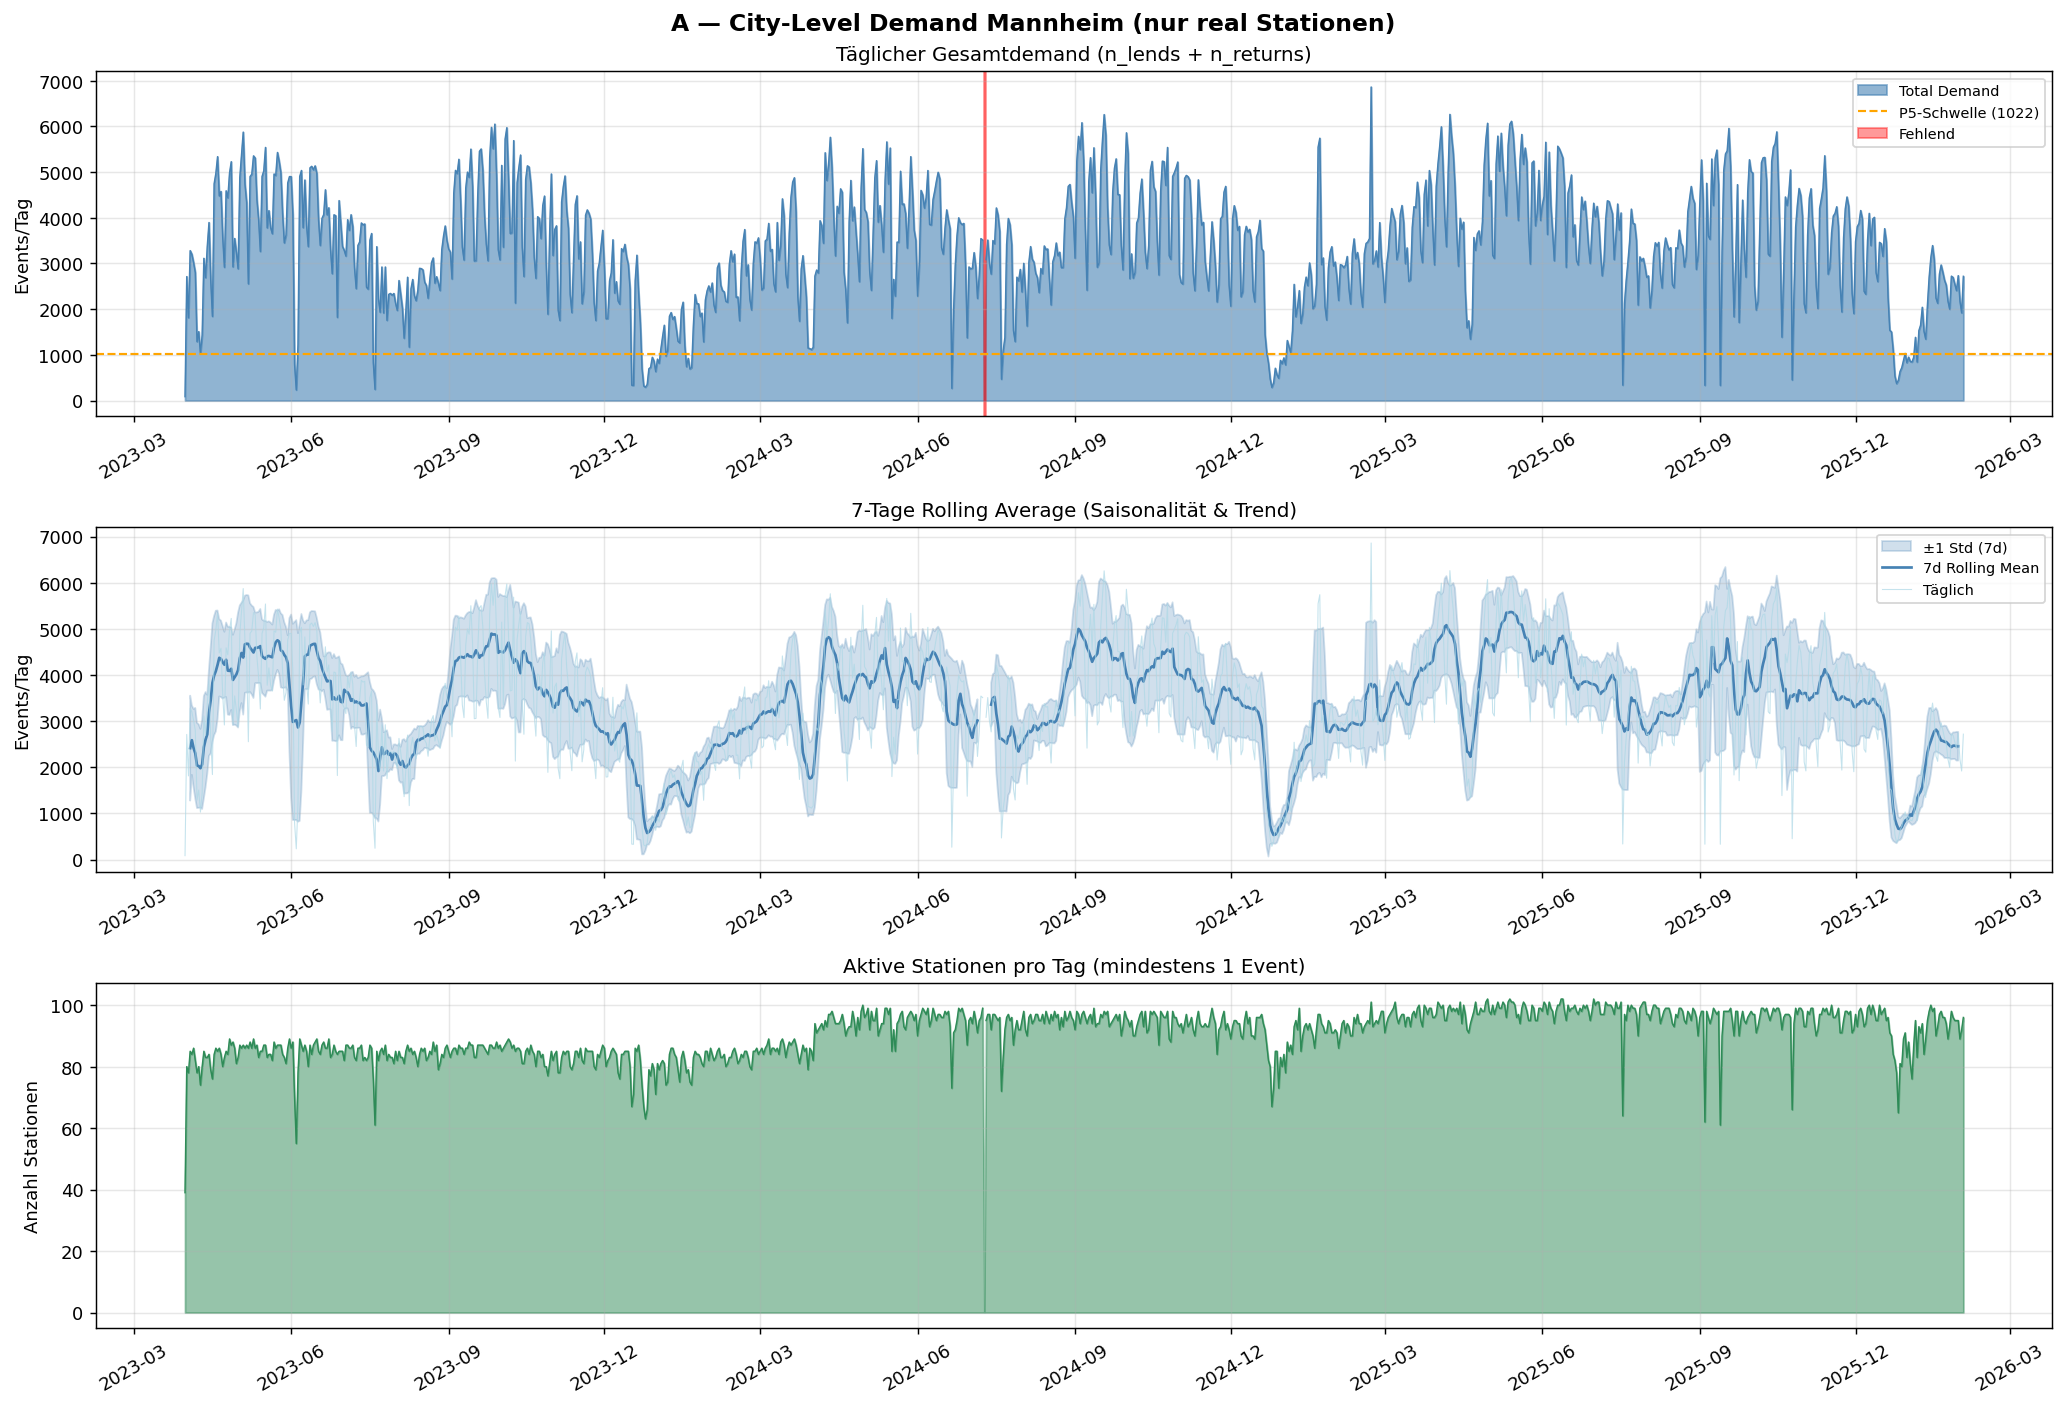

✅ Plot A1 gespeichert.


In [6]:
# ── PLOT A1: City-Level Demand über Zeit ──
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=False)
fig.suptitle('A — City-Level Demand Mannheim (nur real Stationen)', fontsize=13, fontweight='bold')

# A1a: Täglicher Demand (vollständig)
ax = axes[0]
ax.fill_between(daily_city_full['date'], daily_city_full['total_demand'].fillna(0),
                alpha=0.6, color='steelblue', label='Total Demand')
ax.plot(daily_city_full['date'], daily_city_full['total_demand'], color='steelblue', lw=0.8)
ax.axhline(low_days_threshold, color='orange', ls='--', lw=1.2, label=f'P5-Schwelle ({low_days_threshold:.0f})')

# Lücken rot markieren
for d in missing_days['date']:
    ax.axvspan(d, d + pd.Timedelta(days=1), color='red', alpha=0.4, label='Fehlend')
for d in zero_days['date']:
    ax.axvspan(d, d + pd.Timedelta(days=1), color='crimson', alpha=0.6)

ax.set_title('Täglicher Gesamtdemand (n_lends + n_returns)')
ax.set_ylabel('Events/Tag')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=8)
ax.grid(alpha=0.3)

# A1b: 7-Tage Rolling Average mit Konfidenzband
ax = axes[1]
roll = daily_city_full['total_demand'].rolling(7, center=True)
ax.fill_between(daily_city_full['date'],
                roll.mean() - roll.std(), roll.mean() + roll.std(),
                alpha=0.25, color='steelblue', label='±1 Std (7d)')
ax.plot(daily_city_full['date'], roll.mean(), color='steelblue', lw=1.5, label='7d Rolling Mean')
ax.plot(daily_city_full['date'], daily_city_full['total_demand'],
        color='lightblue', lw=0.6, alpha=0.7, label='Täglich')
ax.set_title('7-Tage Rolling Average (Saisonalität & Trend)')
ax.set_ylabel('Events/Tag')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# A1c: Aktive Stationen pro Tag
ax = axes[2]
ax.fill_between(daily_city_full['date'], daily_city_full['active_stations'].fillna(0),
                alpha=0.5, color='seagreen')
ax.plot(daily_city_full['date'], daily_city_full['active_stations'], color='seagreen', lw=0.8)
ax.set_title('Aktive Stationen pro Tag (mindestens 1 Event)')
ax.set_ylabel('Anzahl Stationen')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('✅ Plot A1 gespeichert.')

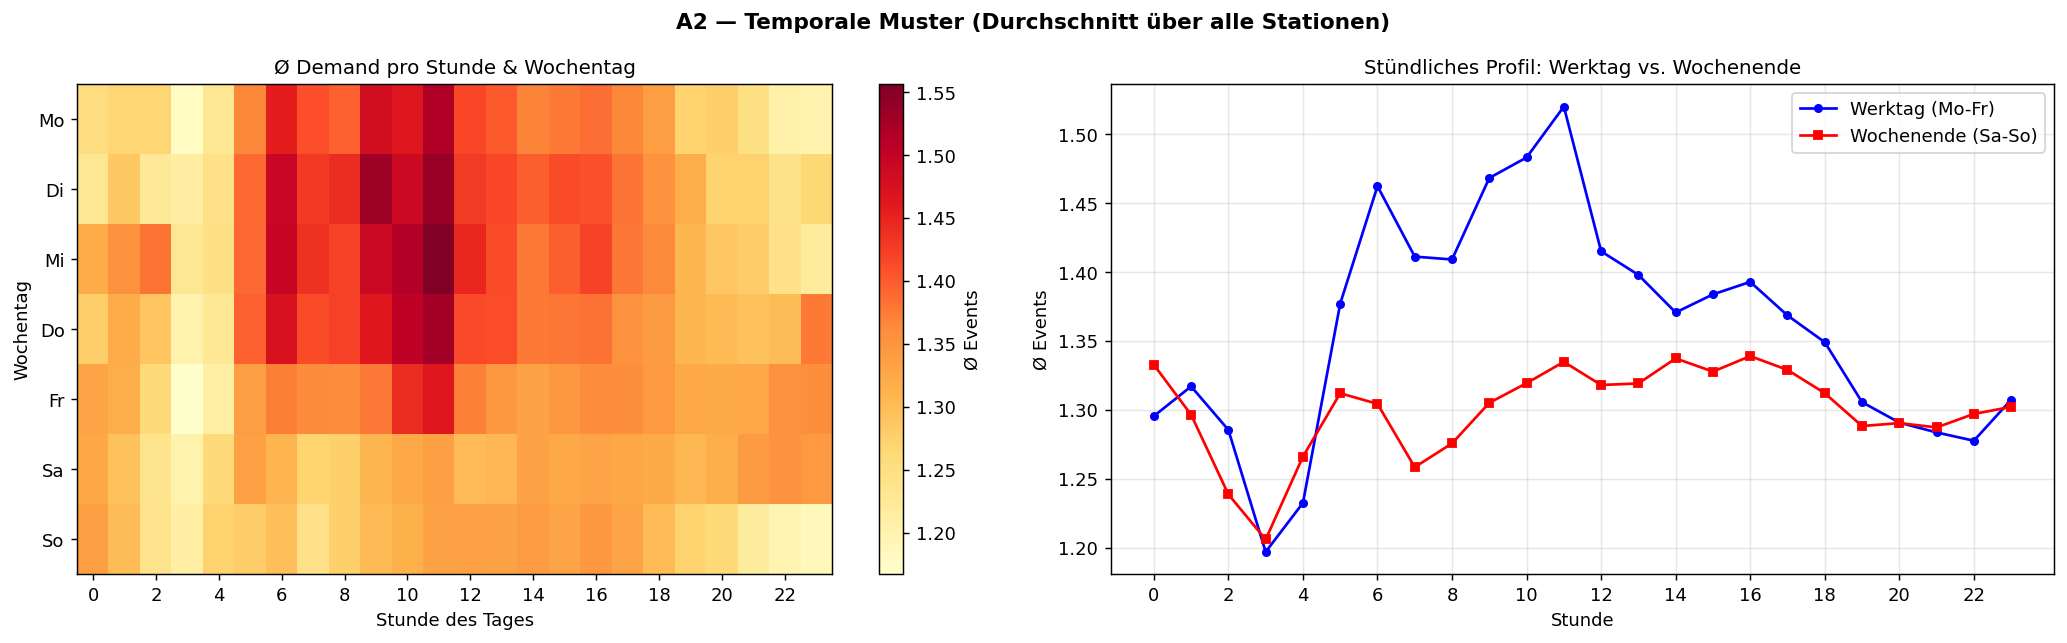


📊 Peak-Stunde Werktag: 11:00 Uhr (1.52 Events Ø)
   Peak-Stunde Wochenende: 16:00 Uhr (1.34 Events Ø)
   Nacht-Minimum (2-5 Uhr): 1.273 Events Ø (Werktag)


In [7]:
# ── PLOT A2: Stündlicher Heatmap (Demand nach Stunde × Wochentag) ──
# Plausibilität der temporalen Muster prüfen
demand_real['hour_of_day'] = demand_real['timestamp'].dt.hour
demand_real['day_of_week'] = demand_real['timestamp'].dt.dayofweek
demand_real['dow_name'] = demand_real['timestamp'].dt.day_name()

pivot_hour_dow = (
    demand_real.groupby(['day_of_week', 'hour_of_day'])['total_demand']
    .mean()
    .unstack(level=1)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('A2 — Temporale Muster (Durchschnitt über alle Stationen)', fontsize=12, fontweight='bold')

# Heatmap
ax = axes[0]
im = ax.imshow(pivot_hour_dow.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_xlabel('Stunde des Tages')
ax.set_ylabel('Wochentag')
ax.set_yticks(range(7))
ax.set_yticklabels(['Mo', 'Di', 'Mi', 'Do', 'Fr', 'Sa', 'So'])
ax.set_xticks(range(0, 24, 2))
ax.set_title('Ø Demand pro Stunde & Wochentag')
plt.colorbar(im, ax=ax, label='Ø Events')

# Stündliches Profil (Werktag vs. Wochenende)
ax = axes[1]
weekday_profile = (
    demand_real[demand_real['day_of_week'] < 5]
    .groupby('hour_of_day')['total_demand'].mean()
)
weekend_profile = (
    demand_real[demand_real['day_of_week'] >= 5]
    .groupby('hour_of_day')['total_demand'].mean()
)
ax.plot(weekday_profile.index, weekday_profile.values, 'b-o', markersize=4, label='Werktag (Mo-Fr)')
ax.plot(weekend_profile.index, weekend_profile.values, 'r-s', markersize=4, label='Wochenende (Sa-So)')
ax.set_xlabel('Stunde')
ax.set_ylabel('Ø Events')
ax.set_title('Stündliches Profil: Werktag vs. Wochenende')
ax.set_xticks(range(0, 24, 2))
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n📊 Peak-Stunde Werktag: {weekday_profile.idxmax()}:00 Uhr ({weekday_profile.max():.2f} Events Ø)')
print(f'   Peak-Stunde Wochenende: {weekend_profile.idxmax()}:00 Uhr ({weekend_profile.max():.2f} Events Ø)')
print(f'   Nacht-Minimum (2-5 Uhr): {weekday_profile[2:6].mean():.3f} Events Ø (Werktag)')

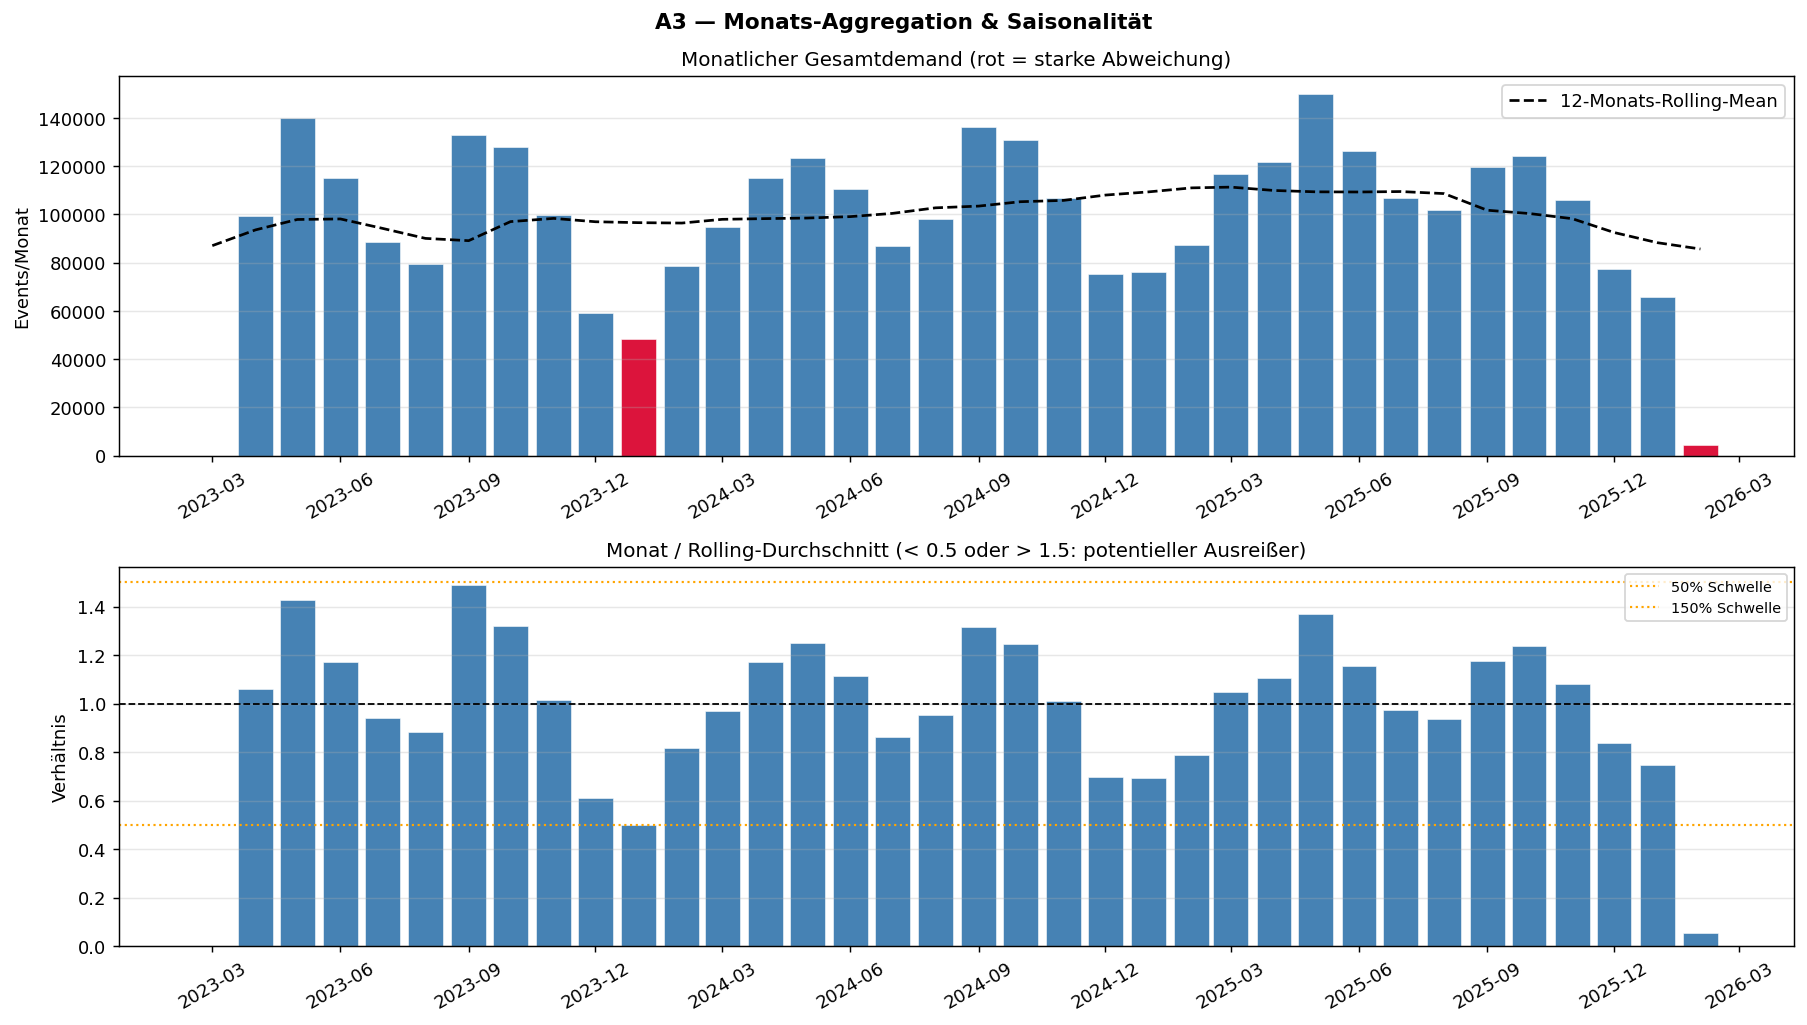


⚠️  Monate < 50% des Durchschnitts: 3
year_month  total_demand  ratio_to_avg
   2023-03            85      0.000976
   2024-01         48269      0.499759
   2026-02          4637      0.054127

⚠️  Monate > 180% des Durchschnitts: 0
✅ Plot A3 gespeichert.


In [8]:
# ── PLOT A3: Monatsaggregation & Saisonalität ──
demand_real['year_month'] = demand_real['timestamp'].dt.to_period('M')
monthly = (
    demand_real.groupby('year_month')['total_demand']
    .sum()
    .reset_index()
)
monthly['year_month_dt'] = monthly['year_month'].dt.to_timestamp()

# Saisonaler Ausreißer-Score: Monat vs. gleitendem 12-Monats-Durchschnitt
monthly['rolling_12'] = monthly['total_demand'].rolling(12, min_periods=4, center=True).mean()
monthly['ratio_to_avg'] = monthly['total_demand'] / monthly['rolling_12']

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('A3 — Monats-Aggregation & Saisonalität', fontsize=12, fontweight='bold')

ax = axes[0]
colors = ['crimson' if (r < 0.5 or r > 2.0) else 'steelblue'
          for r in monthly['ratio_to_avg'].fillna(1)]
ax.bar(monthly['year_month_dt'], monthly['total_demand'], color=colors,
       width=25, edgecolor='white', linewidth=0.3)
ax.plot(monthly['year_month_dt'], monthly['rolling_12'], 'k--', lw=1.5,
        label='12-Monats-Rolling-Mean', zorder=5)
ax.set_title('Monatlicher Gesamtdemand (rot = starke Abweichung)')
ax.set_ylabel('Events/Monat')
ax.legend()
ax.grid(alpha=0.3, axis='y')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

ax = axes[1]
ax.bar(monthly['year_month_dt'], monthly['ratio_to_avg'],
       width=25, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axhline(1.0, color='k', ls='--', lw=1)
ax.axhline(0.5, color='orange', ls=':', lw=1.2, label='50% Schwelle')
ax.axhline(1.5, color='orange', ls=':', lw=1.2, label='150% Schwelle')
ax.set_title('Monat / Rolling-Durchschnitt (< 0.5 oder > 1.5: potentieller Ausreißer)')
ax.set_ylabel('Verhältnis')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, axis='y')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

# Problematische Monate ausgeben
low_months  = monthly[monthly['ratio_to_avg'] < 0.5].dropna()
high_months = monthly[monthly['ratio_to_avg'] > 1.8].dropna()
print(f'\n⚠️  Monate < 50% des Durchschnitts: {len(low_months)}')
if len(low_months) > 0:
    print(low_months[['year_month', 'total_demand', 'ratio_to_avg']].to_string(index=False))
print(f'\n⚠️  Monate > 180% des Durchschnitts: {len(high_months)}')
if len(high_months) > 0:
    print(high_months[['year_month', 'total_demand', 'ratio_to_avg']].to_string(index=False))

In [9]:
# ══════════════════════════════════════════════════════════════
# AUDIT-BLOCK B: Stations-Lebenszyklus
# Fragestellungen:
#   B1. Wann erscheinen / verschwinden Stationen?
#   B2. Gibt es ID-Wechsel (gleicher Ort, neue station_id)?
#   B3. Gibt es Stationen die nur kurz aktiv sind?
#   B4. Wie konsistent ist station_type über die Zeit?
# ══════════════════════════════════════════════════════════════
print('='*60)
print('BLOCK B: Stations-Lebenszyklus')
print('='*60)

# Lebensspanne pro Station (alle Types)
station_lifecycle = (
    demand_raw.groupby('station_id')
    .agg(
        first_seen    = ('timestamp', 'min'),
        last_seen     = ('timestamp', 'max'),
        total_demand  = ('total_demand', 'sum'),
        n_records     = ('total_demand', 'count'),
        station_type  = ('station_type', 'first'),
        station_name_id = ('station_name_id', 'first'),
        location_id   = ('location_id', 'first'),
    )
    .reset_index()
)
station_lifecycle['lifespan_days'] = (
    (station_lifecycle['last_seen'] - station_lifecycle['first_seen']).dt.total_seconds() / 86400
).round(1)

# Aktive vs. inaktive Stationen
data_end = demand_raw['timestamp'].max()
recent_threshold = data_end - pd.Timedelta(days=30)
station_lifecycle['is_currently_active'] = station_lifecycle['last_seen'] >= recent_threshold

# Kurzlebige Stationen (< 14 Tage)
short_lived = station_lifecycle[station_lifecycle['lifespan_days'] < 14]

print(f'Gesamt Stationen: {len(station_lifecycle)}')
print(f'\nStation-Types:')
print(station_lifecycle['station_type'].value_counts().to_string())
print(f'\nNur real-Stationen: {(station_lifecycle["station_type"]=="real").sum()}')
st_real = station_lifecycle[station_lifecycle['station_type'] == 'real']
print(f'  Aktuell aktiv (letzte 30d): {st_real["is_currently_active"].sum()}')
print(f'  Inaktiv / historisch:       {(~st_real["is_currently_active"]).sum()}')
print(f'  Kurzlebig (< 14 Tage):      {(short_lived["station_type"]=="real").sum()}')
print(f'\nLebensspanne real Stationen (Tage):')
print(st_real['lifespan_days'].describe().to_string())

BLOCK B: Stations-Lebenszyklus
Gesamt Stationen: 97659

Station-Types:
station_type
bike         97396
recording      133
real           128
only_nums        2

Nur real-Stationen: 128
  Aktuell aktiv (letzte 30d): 101
  Inaktiv / historisch:       27
  Kurzlebig (< 14 Tage):      19

Lebensspanne real Stationen (Tage):
count     128.000000
mean      786.339062
std       392.984379
min         0.000000
25%       655.250000
50%      1038.600000
75%      1038.900000
max      1039.000000


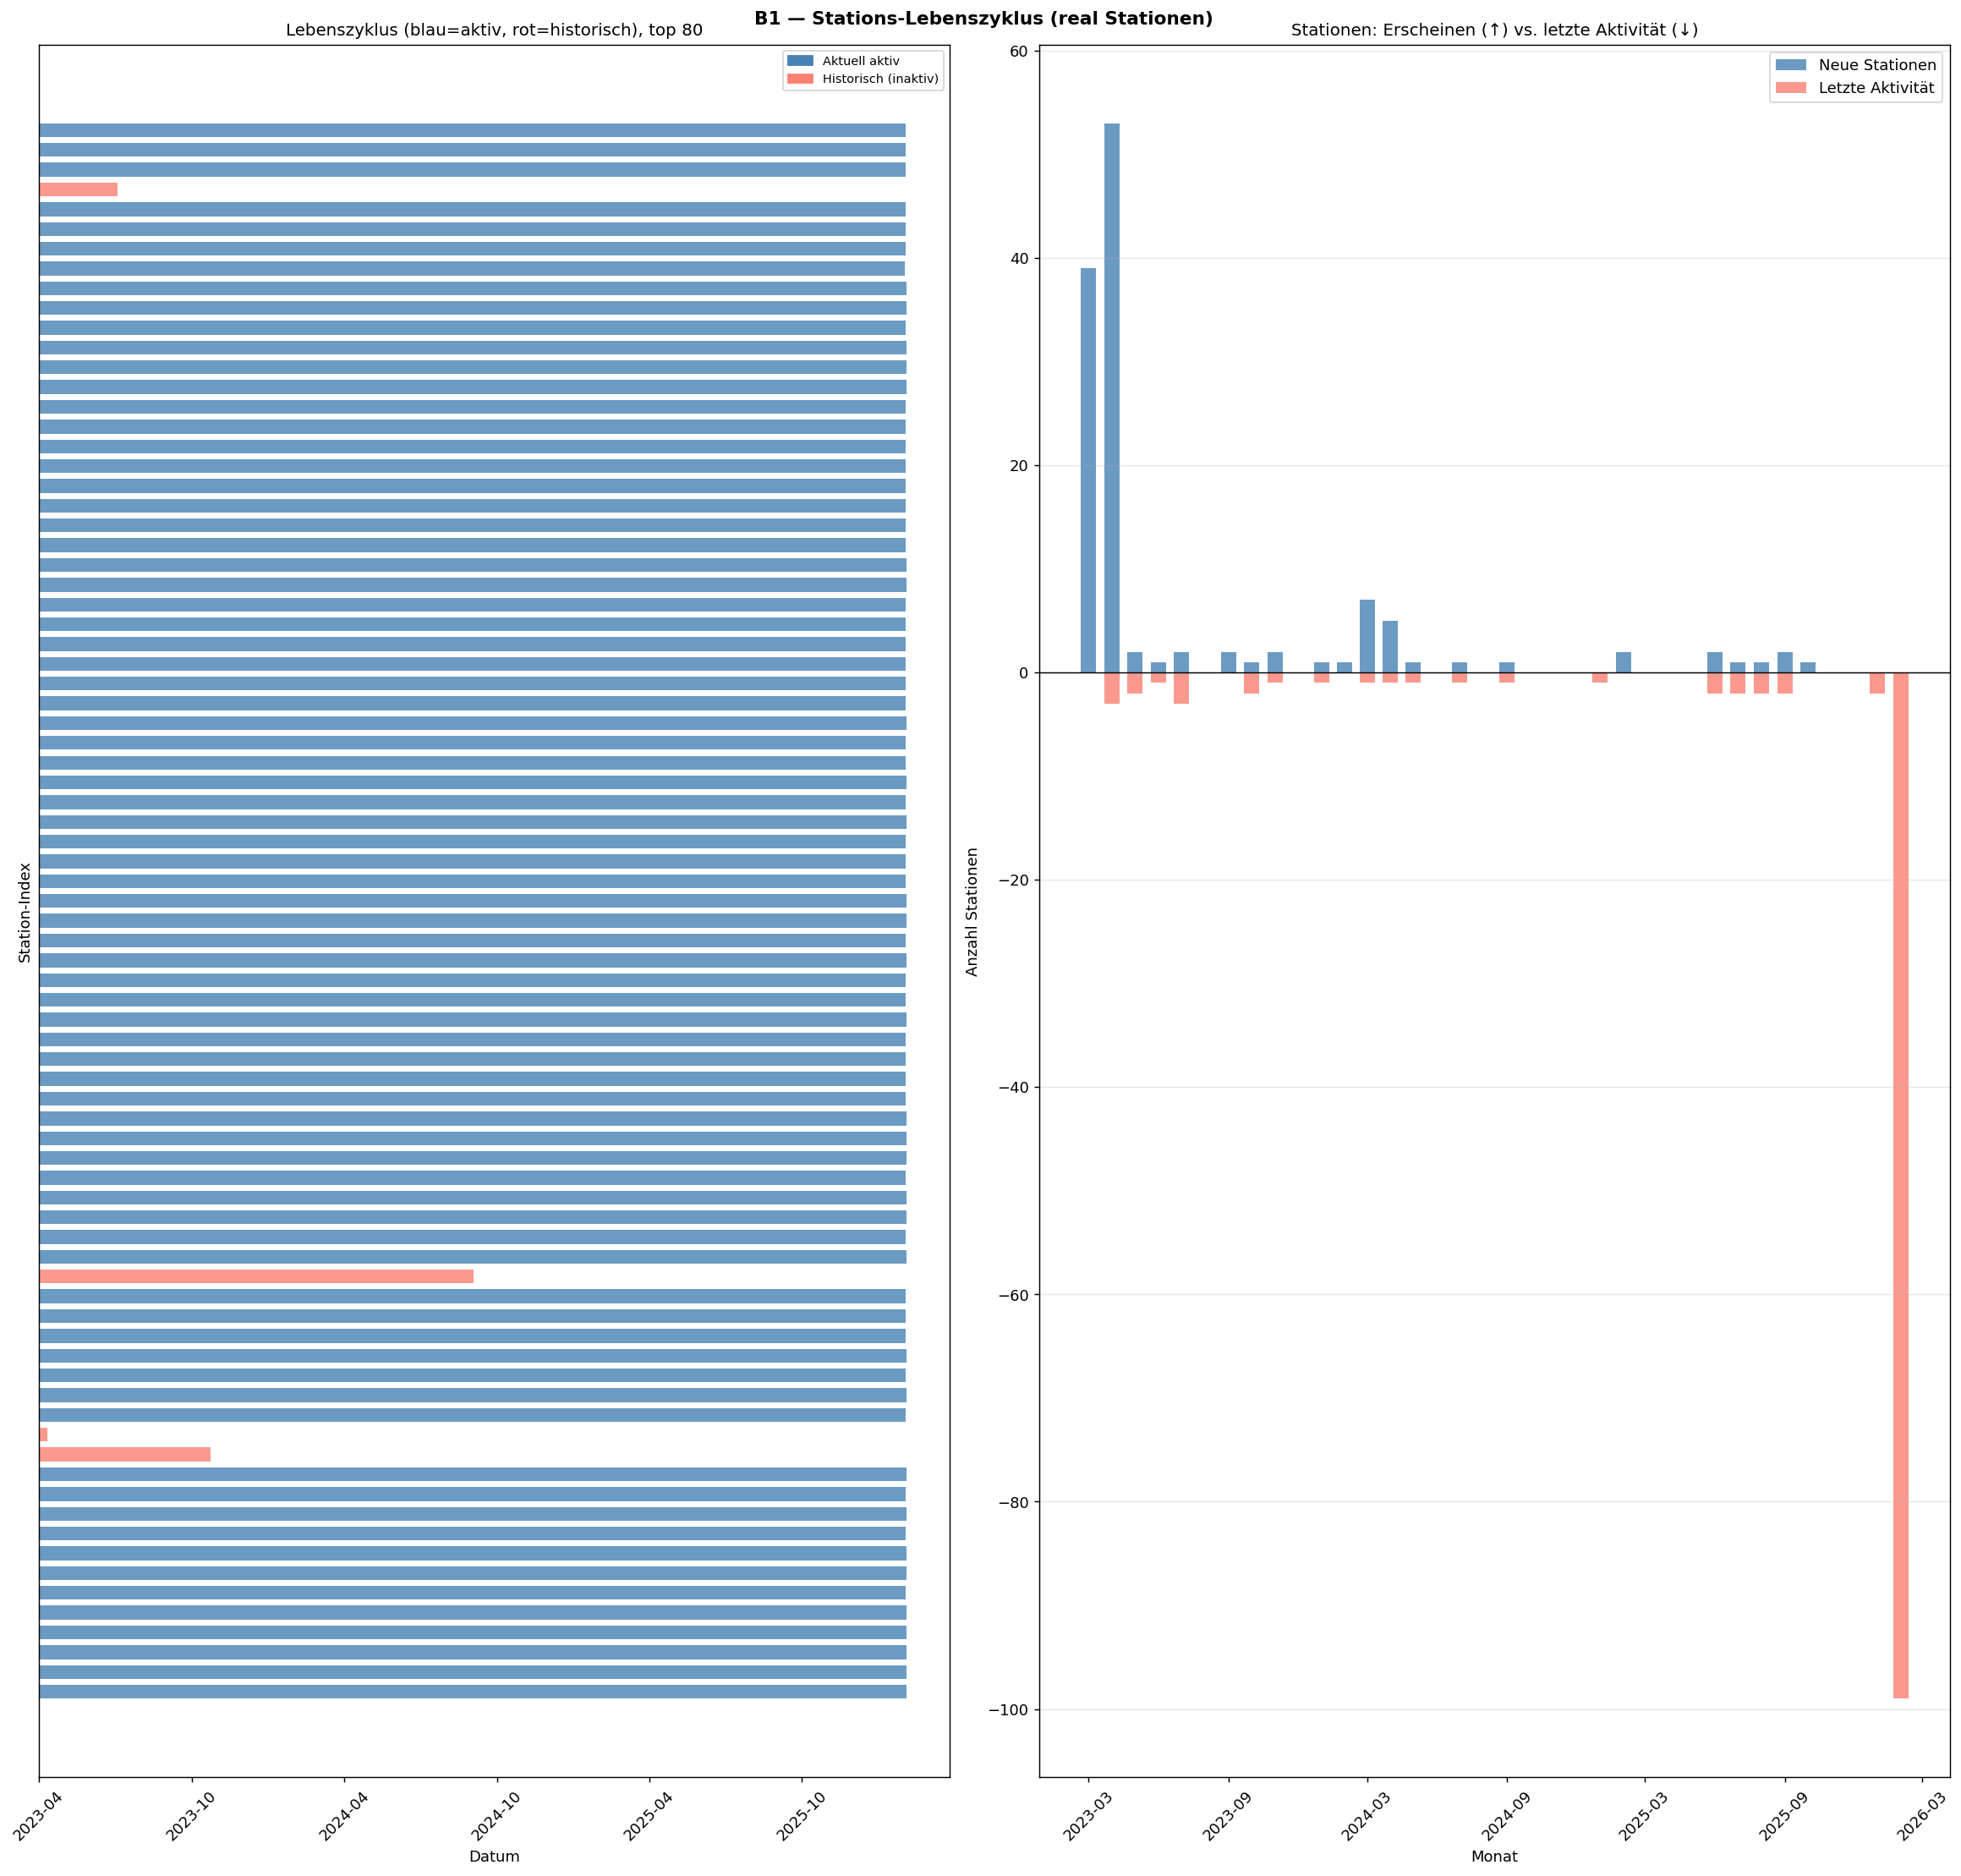

✅ Plot B1 gespeichert.


In [10]:
# ── PLOT B1: Stations-Gantt-Chart (Lebenszyklen) ──
# Nur real Stationen, sortiert nach first_seen
st_real_sorted = st_real.sort_values('first_seen').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(18, max(6, len(st_real_sorted)*0.12 + 2)))
fig.suptitle('B1 — Stations-Lebenszyklus (real Stationen)', fontsize=12, fontweight='bold')

# Gantt (max. 80 Stationen für Lesbarkeit)
ax = axes[0]
n_show = min(80, len(st_real_sorted))
for i, row in st_real_sorted.head(n_show).iterrows():
    color = 'steelblue' if row['is_currently_active'] else 'salmon'
    ax.barh(i, (row['last_seen'] - row['first_seen']).total_seconds() / 86400,
            left=mdates.date2num(row['first_seen'].to_pydatetime()),
            height=0.7, color=color, alpha=0.8)
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.set_xlabel('Datum')
ax.set_ylabel('Station-Index')
ax.set_title(f'Lebenszyklus (blau=aktiv, rot=historisch), top {n_show}')
ax.set_yticks([])
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue', label='Aktuell aktiv'),
    Patch(color='salmon', label='Historisch (inaktiv)')
], fontsize=8)

# Histogram: Wie viele Stationen wurden aktiv pro Monat?
ax = axes[1]
st_real_sorted['first_month'] = st_real_sorted['first_seen'].dt.to_period('M').dt.to_timestamp()
st_real_sorted['last_month']  = st_real_sorted['last_seen'].dt.to_period('M').dt.to_timestamp()

first_seen_counts = st_real_sorted.groupby('first_month').size()
last_seen_counts  = st_real_sorted.groupby('last_month').size()

ax.bar(first_seen_counts.index, first_seen_counts.values, width=20,
       color='steelblue', alpha=0.8, label='Neue Stationen')
ax.bar(last_seen_counts.index, -last_seen_counts.values, width=20,
       color='salmon', alpha=0.8, label='Letzte Aktivität')
ax.axhline(0, color='k', lw=0.8)
ax.set_title('Stationen: Erscheinen (↑) vs. letzte Aktivität (↓)')
ax.set_xlabel('Monat')
ax.set_ylabel('Anzahl Stationen')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f'{AUDIT_OUTPUT}/B1_station_lifecycle.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Plot B1 gespeichert.')

In [11]:
# ── AUDIT B2: Mögliche ID-Wechsel (gleiche location_id, verschiedene station_ids) ──
print('\n─── B2: Mögliche ID-Wechsel ───')

# Prüfe: Mehrere station_ids an derselben location_id
location_station_map = (
    demand_raw[demand_raw['station_type'] == 'real']
    .groupby('location_id')['station_id']
    .nunique()
    .reset_index()
    .rename(columns={'station_id': 'n_station_ids'})
)
multi_id_locations = location_station_map[location_station_map['n_station_ids'] > 1]

print(f'Locations mit mehreren station_ids: {len(multi_id_locations)}')

if len(multi_id_locations) > 0:
    print('\nTop-10 (möglicherweise ID-Wechsel):')
    for loc_id in multi_id_locations.nlargest(10, 'n_station_ids')['location_id']:
        stations_here = (
            demand_raw[(demand_raw['location_id'] == loc_id) & (demand_raw['station_type'] == 'real')]
            .groupby('station_id')
            .agg(first=('timestamp', 'min'), last=('timestamp', 'max'), n=('total_demand', 'sum'))
            .sort_values('first')
        )
        print(f'  location_id={loc_id}: {len(stations_here)} station_ids')
        print(stations_here.to_string())
        print()
else:
    print('  → Keine location_id mit mehreren station_ids gefunden.')

# Prüfe: Stationen mit identischem Namen aber unterschiedlicher ID
station_names_real = station_names[station_names['station_type'] == 'real']
name_duplicates = (
    station_names_real.groupby('station_name')['station_name_id']
    .nunique()
    .reset_index()
    .rename(columns={'station_name_id': 'n_ids'})
)
dup_names = name_duplicates[name_duplicates['n_ids'] > 1]
print(f'\nStation-Namen mit mehreren station_name_ids: {len(dup_names)}')
if len(dup_names) > 0:
    print(dup_names.head(10).to_string(index=False))


─── B2: Mögliche ID-Wechsel ───
Locations mit mehreren station_ids: 8

Top-10 (möglicherweise ID-Wechsel):
  location_id=9506: 2 station_ids
                               first                      last    n
station_id                                                         
171582906  2023-04-20 09:25:00+00:00 2023-06-02 16:05:00+00:00  239
95252421   2024-04-24 08:50:00+00:00 2025-05-21 12:30:00+00:00  382

  location_id=9859: 2 station_ids
                               first                      last      n
station_id                                                           
660937     2023-03-31 23:25:00+00:00 2024-09-02 08:30:00+00:00  25432
345449841  2024-01-14 09:05:00+00:00 2024-01-14 11:30:00+00:00      2

  location_id=10027: 2 station_ids
                               first                      last      n
station_id                                                           
142863936  2023-03-31 23:15:00+00:00 2023-10-24 04:05:00+00:00  24686
58196168   2023-04-01 05:

In [12]:
# ── AUDIT B3: Datenlücken auf Stationsebene (lange Inaktivitätsphasen) ──
print('\n─── B3: Inaktivitätsphasen pro Station ───')

# Pro Station: Tage mit mindestens 1 Event
station_daily = (
    demand_real
    .groupby(['station_id', 'date'])['total_demand']
    .sum()
    .reset_index()
)

# Längste Lücke (aufeinanderfolgende Tage ohne Daten) pro Station
def max_gap_days(dates, total_dates):
    """Größte Lücke in Tagen für eine Station."""
    if len(dates) < 2: return 0
    sorted_dates = sorted(pd.to_datetime(dates))
    gaps = [(sorted_dates[i+1] - sorted_dates[i]).days - 1
            for i in range(len(sorted_dates)-1)]
    return max(gaps) if gaps else 0

station_gaps = (
    station_daily
    .groupby('station_id')
    .apply(lambda g: pd.Series({
        'active_days': len(g),
        'total_demand': g['total_demand'].sum(),
        'max_gap_days': max_gap_days(g['date'].tolist(), None)
    }))
    .reset_index()
)

print(f'\nTop-20 Stationen mit größter Datenlücke:')
top_gaps = station_gaps.nlargest(20, 'max_gap_days')
print(top_gaps[['station_id', 'active_days', 'max_gap_days', 'total_demand']].to_string(index=False))

print(f'\nStationen mit Lücke > 30 Tage: {(station_gaps["max_gap_days"] > 30).sum()}')
print(f'Stationen mit Lücke > 90 Tage: {(station_gaps["max_gap_days"] > 90).sum()}')
print(f'Stationen mit Lücke > 180 Tage: {(station_gaps["max_gap_days"] > 180).sum()}')


─── B3: Inaktivitätsphasen pro Station ───

Top-20 Stationen mit größter Datenlücke:
station_id  active_days  max_gap_days  total_demand
 146888468          507           489          5822
  95252421          205           281          1702
 146888651          778           174          5100
 146888993          832           174         18690
  29111804          914            91          9369
 260511828          434            18          1122
 171582906           43            16           595
  57585616          686            16          3876
  38930131          570            15          1406
 260511069          346            13           806
  34525897          723            10          3208
  24559076          937             9          4094
 260511632          552             9          1618
  33282236          940             9          9107
 378595862          348             8           982
  38930139          341             8           923
  57585097          952       

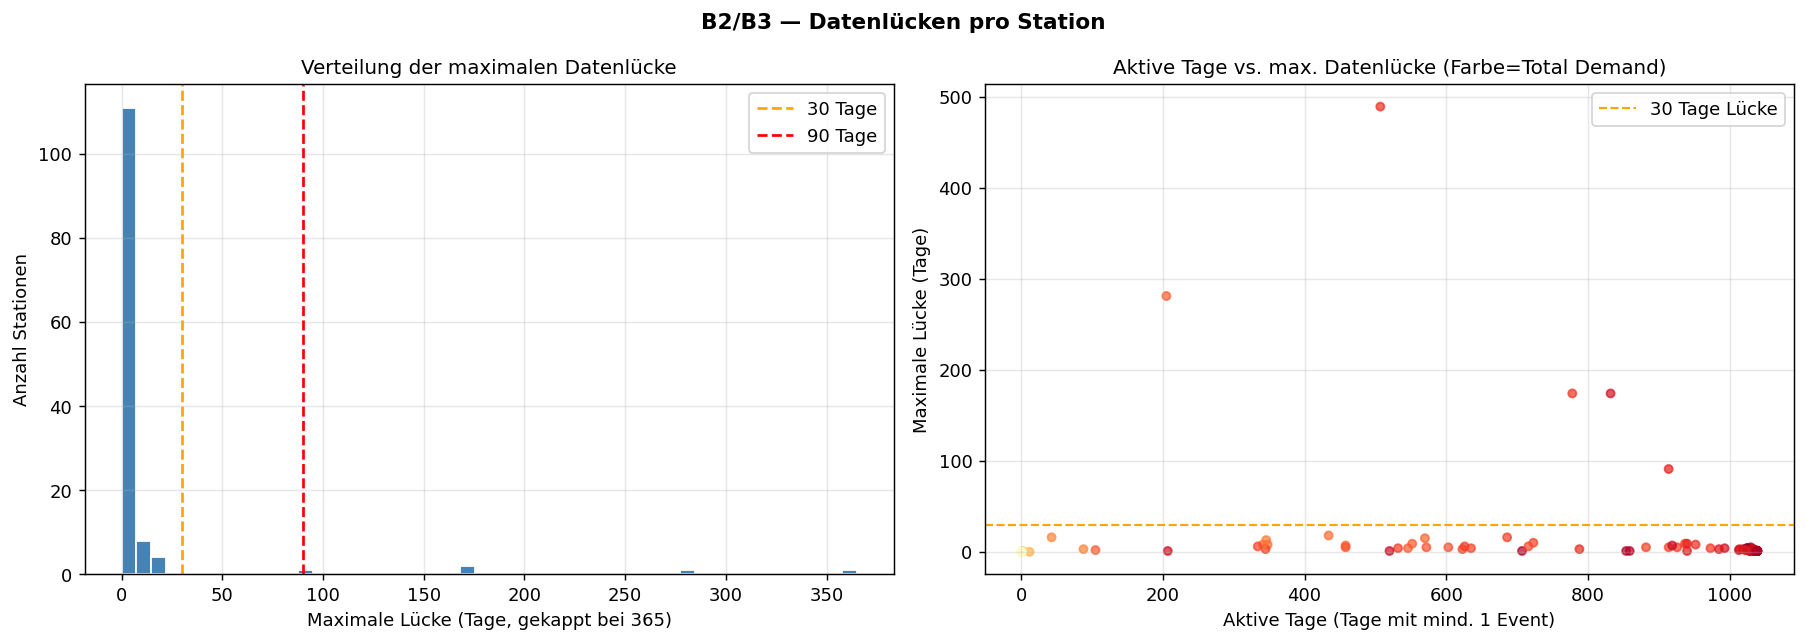

✅ Plot B2 gespeichert.


In [13]:
# ── PLOT B2: Gap-Verteilung ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('B2/B3 — Datenlücken pro Station', fontsize=12, fontweight='bold')

ax = axes[0]
ax.hist(station_gaps['max_gap_days'].clip(upper=365), bins=50, color='steelblue', edgecolor='white')
ax.axvline(30, color='orange', ls='--', lw=1.5, label='30 Tage')
ax.axvline(90, color='red', ls='--', lw=1.5, label='90 Tage')
ax.set_xlabel('Maximale Lücke (Tage, gekappt bei 365)')
ax.set_ylabel('Anzahl Stationen')
ax.set_title('Verteilung der maximalen Datenlücke')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(station_gaps['active_days'], station_gaps['max_gap_days'],
           c=station_gaps['total_demand'], cmap='YlOrRd',
           s=20, alpha=0.7, norm=LogNorm())
ax.axhline(30, color='orange', ls='--', lw=1.2, label='30 Tage Lücke')
ax.set_xlabel('Aktive Tage (Tage mit mind. 1 Event)')
ax.set_ylabel('Maximale Lücke (Tage)')
ax.set_title('Aktive Tage vs. max. Datenlücke (Farbe=Total Demand)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{AUDIT_OUTPUT}/B2_station_gaps.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Plot B2 gespeichert.')

In [14]:
# ══════════════════════════════════════════════════════════════
# AUDIT-BLOCK C: Datenqualität pro Station
# Fragestellungen:
#   C1. Zero-Inflation: Wie viele Stunden haben Demand=0?
#   C2. Demand-Verteilung: Poisson oder Gauß?
#   C3. Gibt es Doppelzählungen (n_lends + n_returns unplausibel hoch)?
#   C4. Stundenaggregation: Wie viele Rohdatensätze pro Stunde/Station?
# ══════════════════════════════════════════════════════════════
print('='*60)
print('BLOCK C: Datenqualität pro Station')
print('='*60)

# Stündliche Aggregation (analog zu V4 Pipeline)
demand_real['hour_ts'] = demand_real['timestamp'].dt.floor('h')
hourly = (
    demand_real
    .groupby(['station_id', 'hour_ts'])
    .agg(n_lends=('n_lends', 'sum'), n_returns=('n_returns', 'sum'), n_records=('total_demand', 'count'))
    .reset_index()
)
hourly['total_demand'] = hourly['n_lends'] + hourly['n_returns']

# Alle Stunden lückenfüllen
all_hours = pd.date_range(hourly['hour_ts'].min(), hourly['hour_ts'].max(), freq='h', tz='UTC')
station_ids = hourly['station_id'].unique()
full_idx = pd.MultiIndex.from_product([station_ids, all_hours], names=['station_id', 'hour_ts'])
hourly_full = (
    hourly.set_index(['station_id', 'hour_ts'])
    .reindex(full_idx, fill_value=0)
    .reset_index()
)

# Zero-Inflation pro Station
zero_rate = (
    hourly_full.groupby('station_id')['total_demand']
    .apply(lambda x: (x == 0).mean())
    .reset_index()
    .rename(columns={'total_demand': 'zero_rate'})
)

print(f'\nZero-Rate (Anteil Stunden mit Demand=0):')
print(zero_rate['zero_rate'].describe().to_string())
print(f'\nStationen mit >90% Zero-Rate: {(zero_rate["zero_rate"] > 0.9).sum()}')
print(f'Stationen mit >99% Zero-Rate: {(zero_rate["zero_rate"] > 0.99).sum()}')

# Doppelzählungscheck: Stunden mit extrem hohem Demand
q99_5 = hourly_full['total_demand'].quantile(0.995)
extreme_events = hourly_full[hourly_full['total_demand'] > q99_5]
print(f'\nP99.5 Stunden-Demand: {q99_5:.0f} Events')
print(f'Stunden über P99.5 ({q99_5:.0f} Events):')
extreme_top = extreme_events.nlargest(15, 'total_demand')[['station_id', 'hour_ts', 'n_lends', 'n_returns', 'total_demand', 'n_records']]
print(extreme_top.to_string(index=False))

# Records pro Stunde/Station (Duplikat-Check)
print(f'\nRecords pro Stunden-Slot (Duplikate?):')
print(hourly['n_records'].value_counts().head(10).to_string())
multi_records = hourly[hourly['n_records'] > 3]
print(f'\nSlots mit > 3 Records: {len(multi_records)} ({len(multi_records)/len(hourly)*100:.2f}%)')

BLOCK C: Datenqualität pro Station

Zero-Rate (Anteil Stunden mit Demand=0):
count    128.000000
mean       0.669098
std        0.264729
min        0.100213
25%        0.423407
50%        0.678510
75%        0.932099
max        0.999960

Stationen mit >90% Zero-Rate: 39
Stationen mit >99% Zero-Rate: 20

P99.5 Stunden-Demand: 17 Events
Stunden über P99.5 (17 Events):
station_id                   hour_ts  n_lends  n_returns  total_demand  n_records
    660951 2023-10-10 09:00:00+00:00       60         59           119          9
    339472 2023-10-10 09:00:00+00:00       57         58           115          9
  27230961 2025-05-10 14:00:00+00:00       94          0            94          9
  27230961 2025-04-27 19:00:00+00:00       87          1            88          7
    660951 2023-09-18 06:00:00+00:00        1         81            82         10
    339468 2024-09-03 10:00:00+00:00       48         32            80         12
    339468 2024-09-09 11:00:00+00:00       40         40 

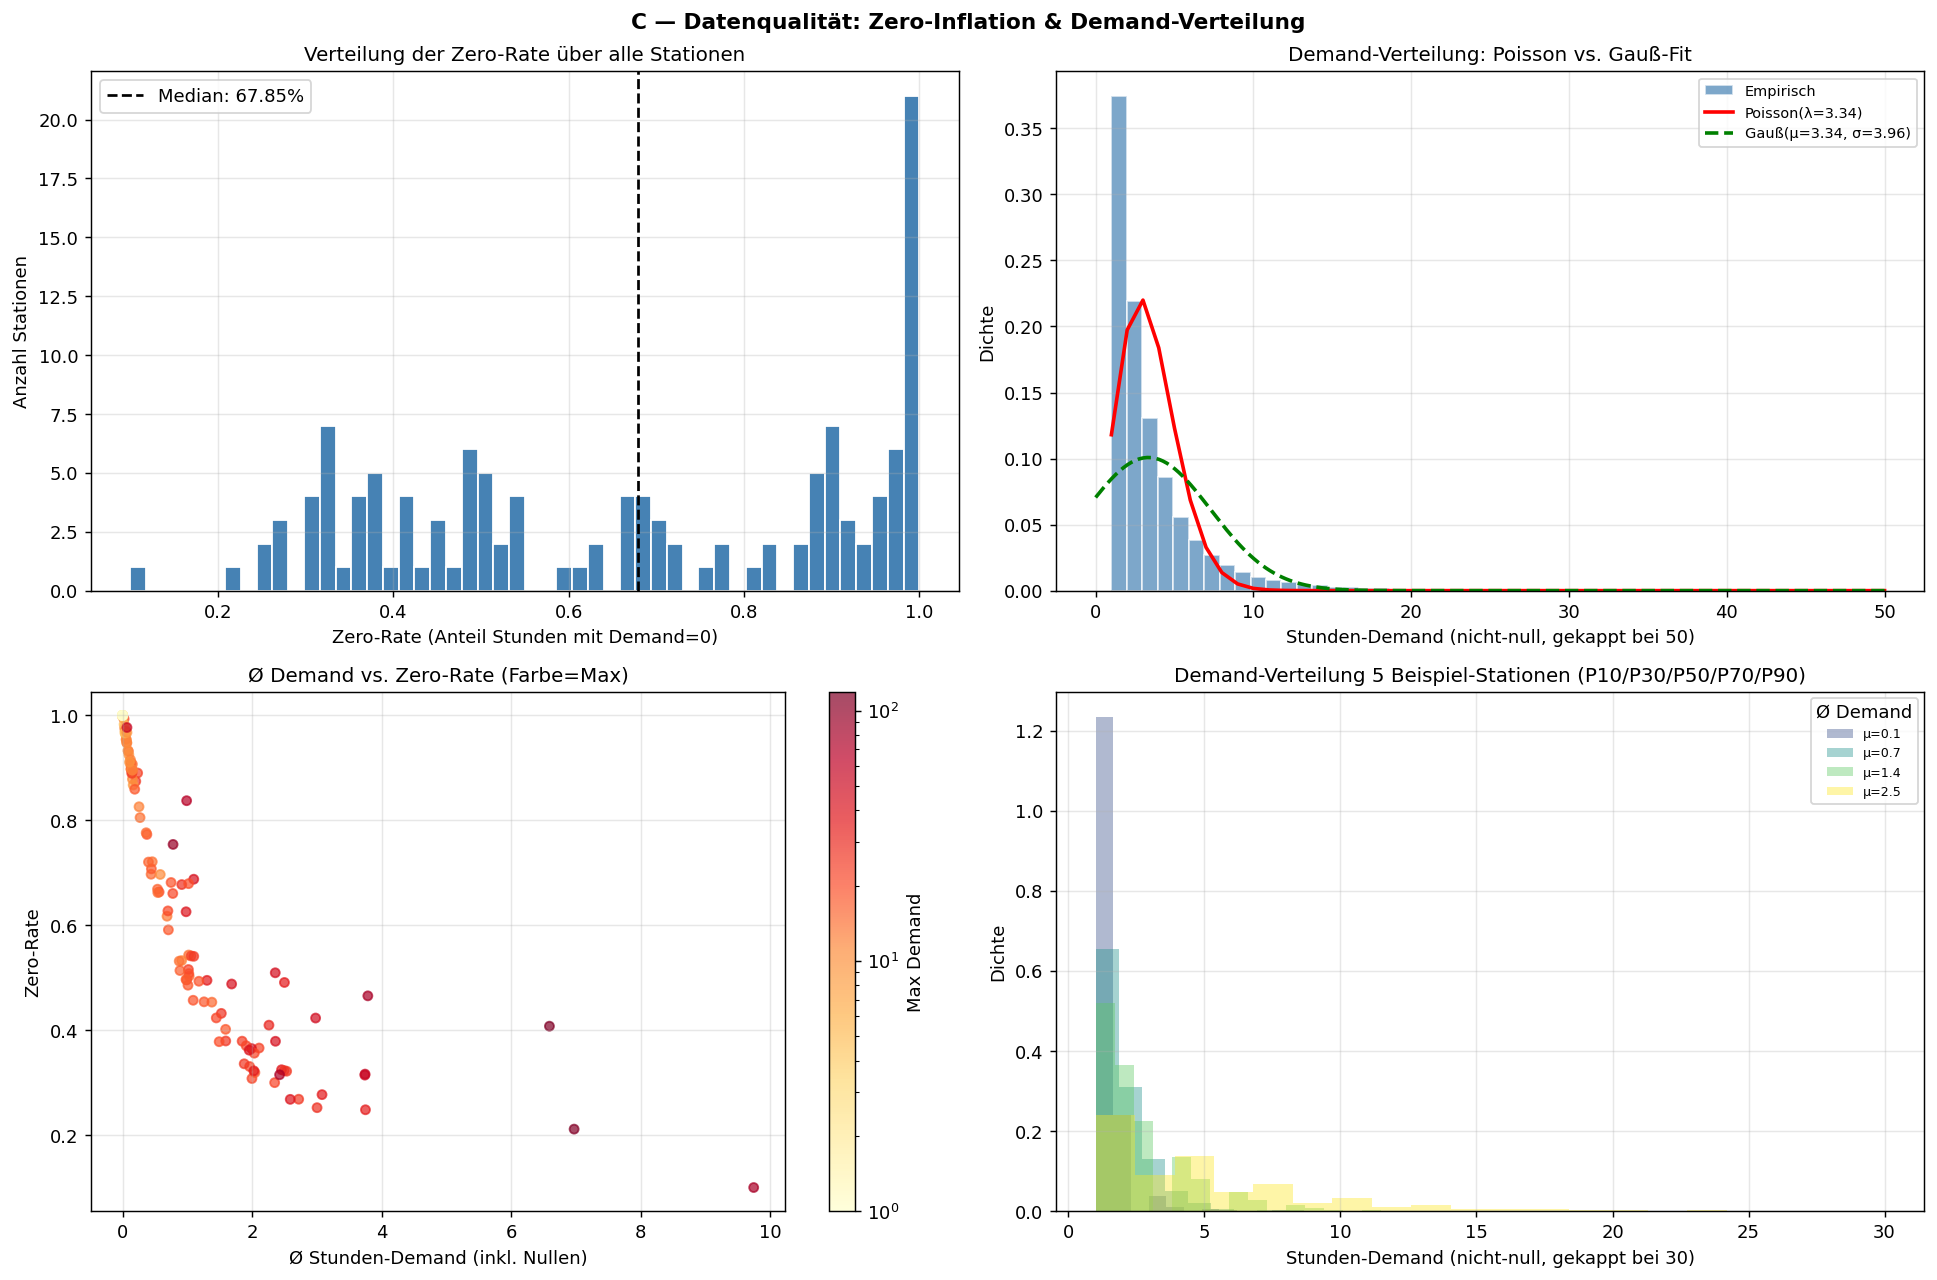

✅ Plot C1 gespeichert.


In [15]:
# ── PLOT C1: Zero-Inflation & Demand-Verteilung ──
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('C — Datenqualität: Zero-Inflation & Demand-Verteilung', fontsize=12, fontweight='bold')

# C1a: Zero-Rate Histogram
ax = axes[0, 0]
ax.hist(zero_rate['zero_rate'], bins=50, color='steelblue', edgecolor='white')
ax.axvline(zero_rate['zero_rate'].median(), color='k', ls='--', lw=1.5,
           label=f'Median: {zero_rate["zero_rate"].median():.2%}')
ax.set_xlabel('Zero-Rate (Anteil Stunden mit Demand=0)')
ax.set_ylabel('Anzahl Stationen')
ax.set_title('Verteilung der Zero-Rate über alle Stationen')
ax.legend()
ax.grid(alpha=0.3)

# C1b: Demand-Verteilung (nicht-null Stunden, alle Stationen)
ax = axes[0, 1]
nonzero_demand = hourly_full[hourly_full['total_demand'] > 0]['total_demand']
ax.hist(nonzero_demand.clip(upper=50), bins=50, density=True,
        color='steelblue', edgecolor='white', alpha=0.7, label='Empirisch')

# Poisson-Fit
lam = nonzero_demand.mean()
x_range = np.arange(1, 51)
poisson_pmf = poisson.pmf(x_range, lam)
ax.plot(x_range, poisson_pmf, 'r-', lw=2, label=f'Poisson(λ={lam:.2f})')

# Normalverteilung-Fit
mu, sigma = nonzero_demand.mean(), nonzero_demand.std()
x_cont = np.linspace(0, 50, 200)
ax.plot(x_cont, norm.pdf(x_cont, mu, sigma), 'g--', lw=2, label=f'Gauß(μ={mu:.2f}, σ={sigma:.2f})')

ax.set_xlabel('Stunden-Demand (nicht-null, gekappt bei 50)')
ax.set_ylabel('Dichte')
ax.set_title('Demand-Verteilung: Poisson vs. Gauß-Fit')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# C1c: Pro-Station mittlerer Demand vs. Zero-Rate
ax = axes[1, 0]
station_stats = (
    hourly_full.groupby('station_id')['total_demand']
    .agg(['mean', 'std', 'max'])
    .reset_index()
)
station_stats = station_stats.merge(zero_rate, on='station_id')
sc = ax.scatter(station_stats['mean'], station_stats['zero_rate'],
                c=station_stats['max'], cmap='YlOrRd', s=25, alpha=0.7,
                norm=LogNorm(vmin=1))
plt.colorbar(sc, ax=ax, label='Max Demand')
ax.set_xlabel('Ø Stunden-Demand (inkl. Nullen)')
ax.set_ylabel('Zero-Rate')
ax.set_title('Ø Demand vs. Zero-Rate (Farbe=Max)')
ax.grid(alpha=0.3)

# C1d: KDE der log(Demand+1) Verteilung pro Stationstyp
ax = axes[1, 1]
# Wähle 5 Stationen mit verschiedenen Aktivitätsniveaus aus
activity_quantiles = station_stats['mean'].quantile([0.1, 0.3, 0.5, 0.7, 0.9])
sample_stations = []
for q in activity_quantiles:
    closest = station_stats.iloc[(station_stats['mean'] - q).abs().argsort()[:1]]['station_id'].values[0]
    sample_stations.append(closest)

colors_sample = plt.cm.viridis(np.linspace(0, 1, len(sample_stations)))
for sid, c in zip(sample_stations, colors_sample):
    sdata = hourly_full[hourly_full['station_id'] == sid]['total_demand']
    smean = station_stats[station_stats['station_id'] == sid]['mean'].values[0]
    sdata_nz = sdata[sdata > 0]
    if len(sdata_nz) > 10:
        ax.hist(sdata_nz.clip(upper=30), bins=20, density=True, alpha=0.4,
                color=c, label=f'μ={smean:.1f}')

ax.set_xlabel('Stunden-Demand (nicht-null, gekappt bei 30)')
ax.set_ylabel('Dichte')
ax.set_title('Demand-Verteilung 5 Beispiel-Stationen (P10/P30/P50/P70/P90)')
ax.legend(title='Ø Demand', fontsize=7)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{AUDIT_OUTPUT}/C1_zero_inflation_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Plot C1 gespeichert.')

In [16]:
# ── AUDIT C2: Poisson-Fit pro Station (Labeling-Implikation) ──
# Für z-Score Labeling: Gauß-Annahme. Poisson-verteilt → andere Grenzen!
print('\n─── C2: Poisson-Fit vs. z-Score Labeling ───')

# Pro Station: Gauß z-Score=3 vs. Poisson-ppf(0.9987)
station_dist_stats = (
    hourly_full[hourly_full['total_demand'] > 0]
    .groupby('station_id')['total_demand']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'count': 'n_active_hours'})
    .reset_index()
)

# Schwellenwert Gauß: mu + 3*sigma
station_dist_stats['zscore_threshold'] = (
    station_dist_stats['mean'] + 3 * station_dist_stats['std']
)

# Schwellenwert Poisson: ppf(0.9987) (entspricht z=3 Gauß)
station_dist_stats['poisson_threshold'] = station_dist_stats['mean'].apply(
    lambda lam: poisson.ppf(0.9987, lam) if lam > 0 else 0
)

# Unterschied: Poisson meist konservativer bei kleinen lambda
station_dist_stats['threshold_diff'] = (
    station_dist_stats['zscore_threshold'] - station_dist_stats['poisson_threshold']
)

print('Statistiken (alle aktiven Stunden, pro Station):')
print(station_dist_stats[['mean', 'zscore_threshold', 'poisson_threshold', 'threshold_diff']].describe().to_string())

# Stationen wo z-Score VIEL höher als Poisson (→ z-Score labelt zu wenig)
liberal_zscore = station_dist_stats[station_dist_stats['threshold_diff'] > 5]
print(f'\nStationen wo Gauß-Schwelle > Poisson-Schwelle um >5 Events: {len(liberal_zscore)}')
print('→ z-Score labelt hier WENIGER als Poisson (konservativer).')

# Stationen wo z-Score VIEL niedriger als Poisson (→ z-Score überlabelt)
conservative_zscore = station_dist_stats[station_dist_stats['threshold_diff'] < -5]
print(f'Stationen wo Gauß-Schwelle < Poisson-Schwelle um >5 Events: {len(conservative_zscore)}')
print('→ z-Score labelt hier MEHR als Poisson (könnte Poisson-Rauschen als Anomalie labeln).')


─── C2: Poisson-Fit vs. z-Score Labeling ───
Statistiken (alle aktiven Stunden, pro Station):
             mean  zscore_threshold  poisson_threshold  threshold_diff
count  128.000000        118.000000         128.000000      118.000000
mean     2.490106          8.790946           8.195312        0.375692
std      1.714122          7.168249           3.104628        4.222596
min      1.000000          1.000000           5.000000       -4.000000
25%      1.356097          4.297793           6.000000       -1.900770
50%      2.000000          6.475763           7.000000       -0.966386
75%      3.041056         10.787832           9.000000        1.154048
max     11.130873         41.643396          22.000000       22.016893

Stationen wo Gauß-Schwelle > Poisson-Schwelle um >5 Events: 11
→ z-Score labelt hier WENIGER als Poisson (konservativer).
Stationen wo Gauß-Schwelle < Poisson-Schwelle um >5 Events: 0
→ z-Score labelt hier MEHR als Poisson (könnte Poisson-Rauschen als Anomalie labe

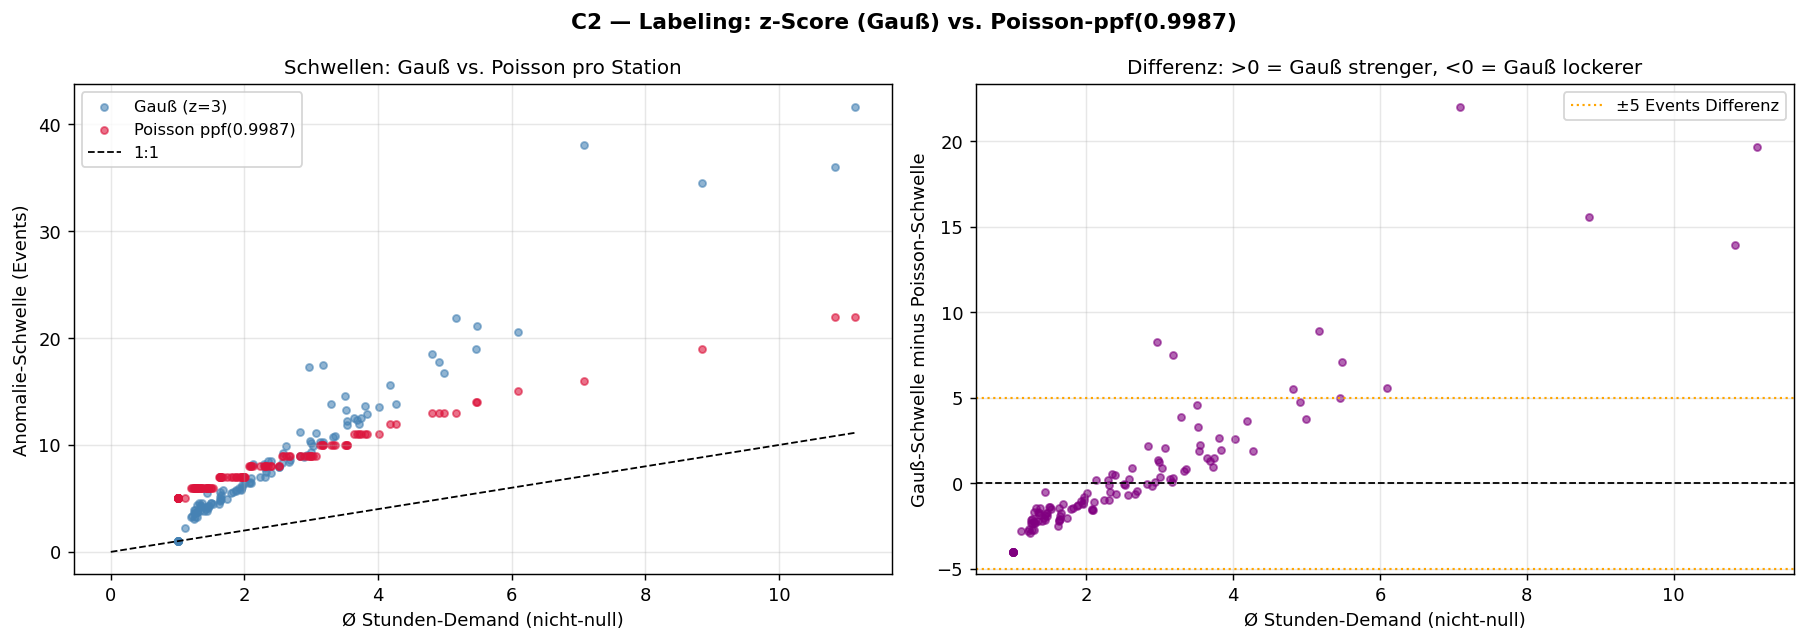

✅ Plot C2 gespeichert.


In [17]:
# ── PLOT C2: Poisson vs. z-Score Schwellen ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('C2 — Labeling: z-Score (Gauß) vs. Poisson-ppf(0.9987)', fontsize=12, fontweight='bold')

ax = axes[0]
ax.scatter(station_dist_stats['mean'], station_dist_stats['zscore_threshold'],
           s=15, alpha=0.6, label='Gauß (z=3)', color='steelblue')
ax.scatter(station_dist_stats['mean'], station_dist_stats['poisson_threshold'],
           s=15, alpha=0.6, label='Poisson ppf(0.9987)', color='crimson')
ax.plot([0, station_dist_stats['mean'].max()],
        [0, station_dist_stats['mean'].max()], 'k--', lw=1, label='1:1')
ax.set_xlabel('Ø Stunden-Demand (nicht-null)')
ax.set_ylabel('Anomalie-Schwelle (Events)')
ax.set_title('Schwellen: Gauß vs. Poisson pro Station')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(station_dist_stats['mean'], station_dist_stats['threshold_diff'],
           s=15, alpha=0.6, color='purple')
ax.axhline(0, color='k', ls='--', lw=1)
ax.axhline(5, color='orange', ls=':', lw=1.2, label='±5 Events Differenz')
ax.axhline(-5, color='orange', ls=':', lw=1.2)
ax.set_xlabel('Ø Stunden-Demand (nicht-null)')
ax.set_ylabel('Gauß-Schwelle minus Poisson-Schwelle')
ax.set_title('Differenz: >0 = Gauß strenger, <0 = Gauß lockerer')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{AUDIT_OUTPUT}/C2_labeling_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Plot C2 gespeichert.')

In [21]:
# ══════════════════════════════════════════════════════════════
# Geo-Informationen laden & WKB → lat/lon dekodieren
# Die 'location'-Spalte ist WKB-Hex → Shapely-Geometrie → lat/lon
# ══════════════════════════════════════════════════════════════
import pyarrow.parquet as pq
from shapely import wkb as shapely_wkb

geo_raw = pq.read_table(GEO_INFO_PATH).to_pandas()
geom = geo_raw['location'].apply(lambda x: shapely_wkb.loads(bytes.fromhex(x)))
geo_raw['latitude']  = geom.apply(lambda g: round(g.y, 6))
geo_raw['longitude'] = geom.apply(lambda g: round(g.x, 6))
geo = geo_raw.drop(columns=['location'])

print(f'Geo geladen: {len(geo):,} Einträge')
print(f'Spalten: {list(geo.columns)}')
print(f'Lat-Bereich: {geo["latitude"].min():.4f} – {geo["latitude"].max():.4f}')
print(f'Lon-Bereich: {geo["longitude"].min():.4f} – {geo["longitude"].max():.4f}')
print(geo.head(3).to_string())

Geo geladen: 300,508 Einträge
Spalten: ['location_id', 'continent_name', 'country_name', 'city_name', 'federal_state_name', 'postal_code', 'elevation', 'latitude', 'longitude']
Lat-Bereich: -70.1630 – 74.8100
Lon-Bereich: -84.7900 – 78.9360
   location_id continent_name country_name      city_name federal_state_name  postal_code  elevation  latitude  longitude
0           29             EU      Germany  Kleinaitingen             Bayern        86507        NaN    48.221     10.831
1          219             EU      Germany      Ettlingen  Baden-Württemberg        76275        NaN    48.923      8.361
2          702             EU      Germany   Rheinstetten  Baden-Württemberg        76287        NaN    48.982      8.326


In [22]:

# ══════════════════════════════════════════════════════════════
# AUDIT-BLOCK D: Geo-Plausibilität
# Fragestellungen:
#   D1. Liegen alle Stationen tatsächlich in Mannheim?
#   D2. Geo-Koordinaten plausibel?
#   D3. Cluster erkennbar (verschiedene Stadtteile)?
# ══════════════════════════════════════════════════════════════
print('='*60)
print('BLOCK D: Geo-Plausibilität')
print('='*60)

# Stationen mit Geo-Informationen verknüpfen
station_with_geo = (
    demand_real[['station_id', 'location_id', 'station_type']]
    .drop_duplicates('station_id')
    .merge(geo[['location_id', 'latitude', 'longitude', 'city_name', 'federal_state_name']],
           on='location_id', how='left')
)

# Mannheim: ca. 49.4° N, 8.5° E
# Bounding Box: ±0.15° Lat, ±0.15° Lon
MA_LAT, MA_LON = 49.4875, 8.4660
BB_DELTA = 0.12

outside_bbox = station_with_geo[
    (station_with_geo['latitude'].notna()) &
    (
        (station_with_geo['latitude'] < MA_LAT - BB_DELTA) |
        (station_with_geo['latitude'] > MA_LAT + BB_DELTA) |
        (station_with_geo['longitude'] < MA_LON - BB_DELTA) |
        (station_with_geo['longitude'] > MA_LON + BB_DELTA)
    )
]

no_geo = station_with_geo[station_with_geo['latitude'].isna()]

print(f'Stationen mit Geo-Koordinaten: {station_with_geo["latitude"].notna().sum()}')
print(f'Stationen OHNE Koordinaten:    {len(no_geo)}')
print(f'Stationen außerhalb Mannheim BBox (±{BB_DELTA}°): {len(outside_bbox)}')

if len(outside_bbox) > 0:
    print('\n⚠️  Stationen außerhalb der Bounding Box:')
    print(outside_bbox[['station_id', 'latitude', 'longitude', 'city_name']].to_string(index=False))

print(f'\nCity-Namen in den Geo-Daten:')
print(station_with_geo['city_name'].value_counts().to_string())

print(f'\nKoordinaten-Bereich der Stationen:')
valid_geo = station_with_geo[station_with_geo['latitude'].notna()]
print(f'  Lat: {valid_geo["latitude"].min():.4f} – {valid_geo["latitude"].max():.4f}')
print(f'  Lon: {valid_geo["longitude"].min():.4f} – {valid_geo["longitude"].max():.4f}')

BLOCK D: Geo-Plausibilität
Stationen mit Geo-Koordinaten: 128
Stationen OHNE Koordinaten:    0
Stationen außerhalb Mannheim BBox (±0.12°): 0

City-Namen in den Geo-Daten:
city_name
Mannheim                 110
Ludwigshafen am Rhein     16
Ilvesheim                  1
Viernheim                  1

Koordinaten-Bereich der Stationen:
  Lat: 49.4520 – 49.5510
  Lon: 8.4000 – 8.5700


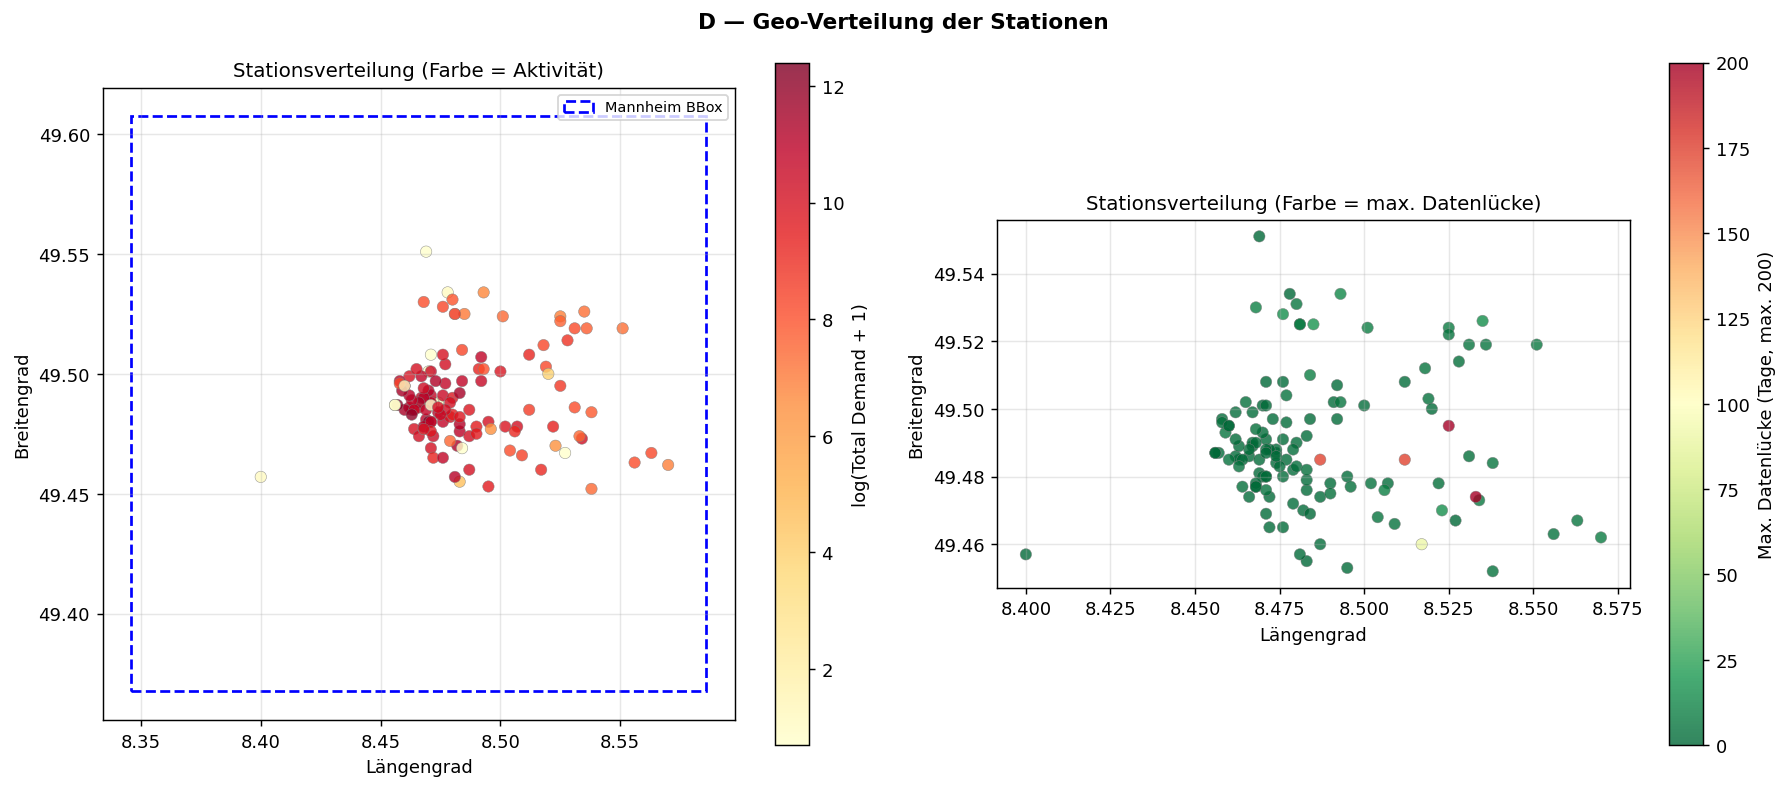

✅ Plot D1 gespeichert.


In [23]:
# ── PLOT D1: Stationsverteilung auf Karte (Scatter) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('D — Geo-Verteilung der Stationen', fontsize=12, fontweight='bold')

# Merge mit Aktivitätsdaten
station_activity_merge = station_gaps.merge(
    station_with_geo[['station_id', 'latitude', 'longitude', 'city_name']],
    on='station_id', how='left'
).dropna(subset=['latitude', 'longitude'])

ax = axes[0]
sc = ax.scatter(
    station_activity_merge['longitude'],
    station_activity_merge['latitude'],
    c=np.log1p(station_activity_merge['total_demand']),
    cmap='YlOrRd', s=40, alpha=0.8, edgecolors='gray', linewidths=0.3
)
plt.colorbar(sc, ax=ax, label='log(Total Demand + 1)')
ax.set_xlabel('Längengrad')
ax.set_ylabel('Breitengrad')
ax.set_title('Stationsverteilung (Farbe = Aktivität)')

# Bounding Box einzeichnen
bbox_rect = plt.Rectangle(
    (MA_LON - BB_DELTA, MA_LAT - BB_DELTA),
    2*BB_DELTA, 2*BB_DELTA,
    fill=False, edgecolor='blue', linestyle='--', linewidth=1.5, label='Mannheim BBox'
)
ax.add_patch(bbox_rect)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.set_aspect('equal')

# Max. Lücke auf Geo-Karte
ax = axes[1]
sc2 = ax.scatter(
    station_activity_merge['longitude'],
    station_activity_merge['latitude'],
    c=station_activity_merge['max_gap_days'].clip(upper=200),
    cmap='RdYlGn_r', s=40, alpha=0.8, edgecolors='gray', linewidths=0.3
)
plt.colorbar(sc2, ax=ax, label='Max. Datenlücke (Tage, max. 200)')
ax.set_xlabel('Längengrad')
ax.set_ylabel('Breitengrad')
ax.set_title('Stationsverteilung (Farbe = max. Datenlücke)')
ax.grid(alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{AUDIT_OUTPUT}/D1_geo_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Plot D1 gespeichert.')

In [24]:
# ══════════════════════════════════════════════════════════════
# AUDIT-BLOCK E: Wetter-Datenlücken
# ══════════════════════════════════════════════════════════════
print('='*60)
print('BLOCK E: Wetter-Datenlücken')
print('='*60)

weather = pd.read_parquet(WEATHER_PATH)
weather['timestamp'] = pd.to_datetime(weather['timestamp'], utc=True)
weather_ma = weather[weather['location_id'] == WEATHER_STATION_ID].copy()

# Stündliche Aggregation
weather_ma['hour_ts'] = weather_ma['timestamp'].dt.floor('h')
weather_hourly = (
    weather_ma.groupby('hour_ts')
    .agg(
        temperature   = ('temperature', 'mean'),
        humidity      = ('humidity', 'mean'),
        precipitation = ('precipitation', 'sum'),
        wind_speed    = ('wind_speed', 'mean'),
        n_records     = ('temperature', 'count')
    )
    .reset_index()
)

# Demand-Zeitraum als Referenz
demand_start = demand_real['timestamp'].min().floor('h')
demand_end   = demand_real['timestamp'].max().floor('h')
all_demand_hours = pd.date_range(demand_start, demand_end, freq='h', tz='UTC')

weather_full = weather_hourly.set_index('hour_ts').reindex(all_demand_hours).reset_index()
weather_full.columns = ['hour_ts'] + list(weather_full.columns[1:])

print(f'Demand-Zeitraum: {demand_start.date()} → {demand_end.date()}')
print(f'Wetter-Zeitraum: {weather_hourly["hour_ts"].min().date()} → {weather_hourly["hour_ts"].max().date()}')
print(f'\nCoverage:')
for col in ['temperature', 'humidity', 'precipitation', 'wind_speed']:
    coverage = weather_full[col].notna().mean() * 100
    n_missing = weather_full[col].isna().sum()
    print(f'  {col:<15}: {coverage:.1f}% ({n_missing:,} fehlende Stunden)')

# Längste Wetter-Lücke
missing_weather = weather_full[weather_full['temperature'].isna()]
if len(missing_weather) > 0:
    # Konsekutive Lücken
    weather_full['is_missing'] = weather_full['temperature'].isna()
    weather_full['gap_id'] = (weather_full['is_missing'] != weather_full['is_missing'].shift()).cumsum()
    gap_lengths = (
        weather_full[weather_full['is_missing']]
        .groupby('gap_id')['hour_ts']
        .agg(['min', 'max', 'count'])
        .rename(columns={'min': 'gap_start', 'max': 'gap_end', 'count': 'gap_hours'})
    )
    print(f'\nTop-10 Wetter-Lücken:')
    print(gap_lengths.nlargest(10, 'gap_hours')[['gap_start', 'gap_end', 'gap_hours']].to_string())
else:
    print('\n✅ Keine Wetter-Lücken im Demand-Zeitraum.')

BLOCK E: Wetter-Datenlücken
Demand-Zeitraum: 2023-03-31 → 2026-02-02
Wetter-Zeitraum: 2023-04-01 → 2026-02-02

Coverage:
  temperature    : 99.7% (66 fehlende Stunden)
  humidity       : 99.7% (66 fehlende Stunden)
  precipitation  : 99.9% (24 fehlende Stunden)
  wind_speed     : 99.7% (72 fehlende Stunden)

Top-10 Wetter-Lücken:
                       gap_start                   gap_end  gap_hours
gap_id                                                               
5      2025-10-04 14:00:00+00:00 2025-10-06 05:00:00+00:00         40
7      2026-02-02 01:00:00+00:00 2026-02-02 23:00:00+00:00         23
3      2025-03-25 10:00:00+00:00 2025-03-25 11:00:00+00:00          2
1      2023-03-31 23:00:00+00:00 2023-03-31 23:00:00+00:00          1


BLOCK F: Lends vs. Returns Balance
Gesamt n_lends:   1,770,907
Gesamt n_returns: 1,760,788
Ratio (lends/returns): 1.0057
Differenz: 10,119 (0.29%)

Stationen mit starker Lend-Dominanz (ratio>2, >100 Events): 0
Stationen mit starker Return-Dominanz (ratio<0.5, >100 Events): 0


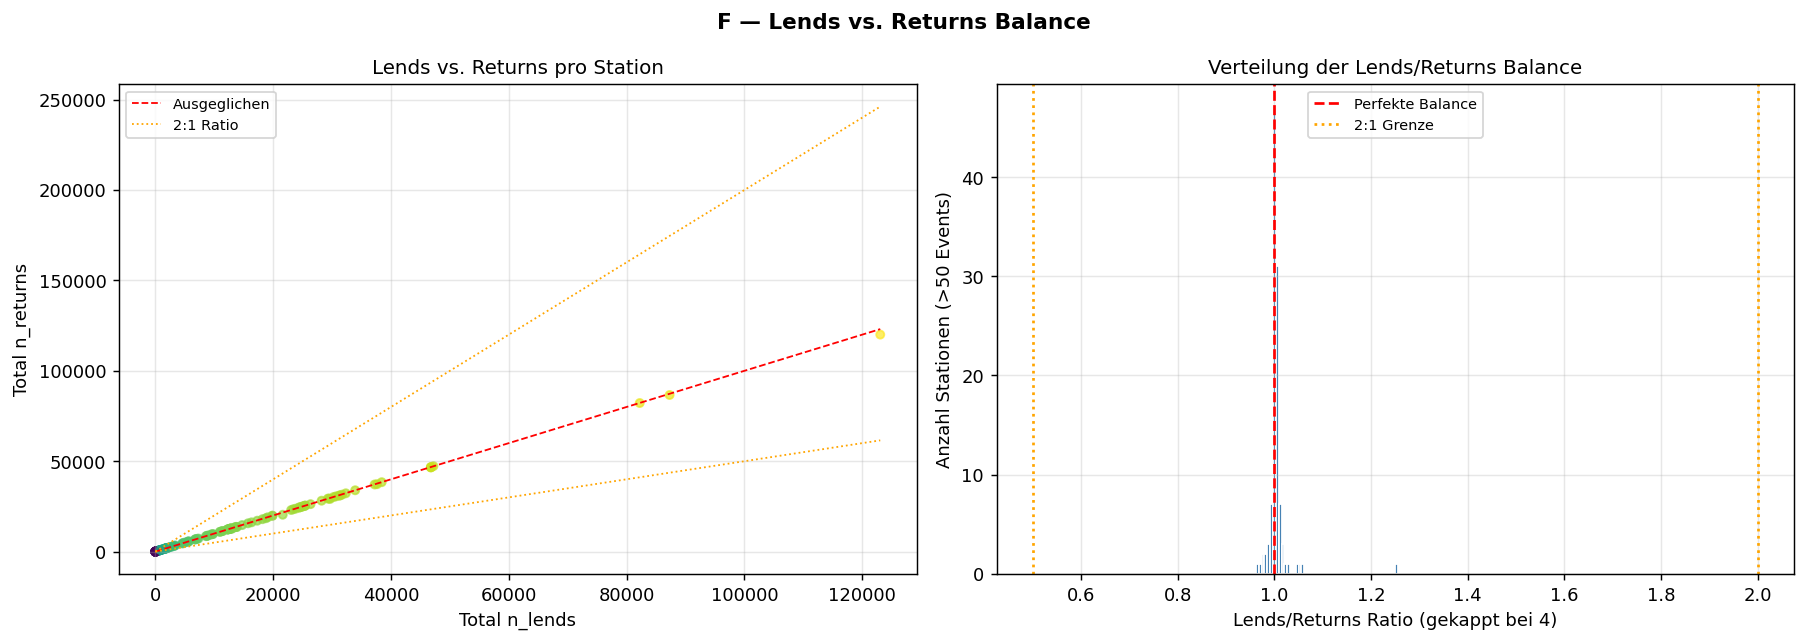

✅ Plot F1 gespeichert.


In [25]:
# ══════════════════════════════════════════════════════════════
# AUDIT-BLOCK F: Lends vs. Returns Balance
# Fragestellung: Plausibles Verhältnis? Starke Imbalance = Problem?
# ══════════════════════════════════════════════════════════════
print('='*60)
print('BLOCK F: Lends vs. Returns Balance')
print('='*60)

# Gesamt-Balance
total_lends   = demand_real['n_lends'].sum()
total_returns = demand_real['n_returns'].sum()
print(f'Gesamt n_lends:   {total_lends:,}')
print(f'Gesamt n_returns: {total_returns:,}')
print(f'Ratio (lends/returns): {total_lends/total_returns:.4f}')
print(f'Differenz: {abs(total_lends - total_returns):,} ({abs(total_lends - total_returns)/(total_lends+total_returns)*100:.2f}%)')

# Pro Station
station_balance = (
    demand_real.groupby('station_id')
    .agg(total_lends=('n_lends', 'sum'), total_returns=('n_returns', 'sum'))
    .reset_index()
)
station_balance['balance_ratio'] = (
    station_balance['total_lends'] /
    (station_balance['total_returns'] + 1)
)
station_balance['total'] = station_balance['total_lends'] + station_balance['total_returns']

# Extreme Imbalance
extreme_source = station_balance[(station_balance['balance_ratio'] > 2) & (station_balance['total'] > 100)]
extreme_sink   = station_balance[(station_balance['balance_ratio'] < 0.5) & (station_balance['total'] > 100)]
print(f'\nStationen mit starker Lend-Dominanz (ratio>2, >100 Events): {len(extreme_source)}')
print(f'Stationen mit starker Return-Dominanz (ratio<0.5, >100 Events): {len(extreme_sink)}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('F — Lends vs. Returns Balance', fontsize=12, fontweight='bold')

ax = axes[0]
ax.scatter(station_balance['total_lends'], station_balance['total_returns'],
           c=np.log1p(station_balance['total']), cmap='viridis', s=20, alpha=0.7)
max_val = max(station_balance['total_lends'].max(), station_balance['total_returns'].max())
ax.plot([0, max_val], [0, max_val], 'r--', lw=1, label='Ausgeglichen')
ax.plot([0, max_val], [0, max_val*2], 'orange', ls=':', lw=1, label='2:1 Ratio')
ax.plot([0, max_val], [0, max_val*0.5], 'orange', ls=':', lw=1)
ax.set_xlabel('Total n_lends')
ax.set_ylabel('Total n_returns')
ax.set_title('Lends vs. Returns pro Station')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(station_balance[station_balance['total'] > 50]['balance_ratio'].clip(0, 4),
        bins=50, color='steelblue', edgecolor='white')
ax.axvline(1.0, color='red', ls='--', lw=1.5, label='Perfekte Balance')
ax.axvline(2.0, color='orange', ls=':', lw=1.5, label='2:1 Grenze')
ax.axvline(0.5, color='orange', ls=':', lw=1.5)
ax.set_xlabel('Lends/Returns Ratio (gekappt bei 4)')
ax.set_ylabel('Anzahl Stationen (>50 Events)')
ax.set_title('Verteilung der Lends/Returns Balance')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{AUDIT_OUTPUT}/F1_lends_returns_balance.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Plot F1 gespeichert.')

BLOCK G: Sampling-Rate & Datendichte
Sampling-Intervalle (Minuten):
count    2.579201e+06
mean     5.619488e+01
std      5.976173e+02
min      1.000000e+00
25%      5.000000e+00
50%      1.500000e+01
75%      4.000000e+01
max      7.058750e+05

Häufigste Intervalle:
time_diff_min
5.0     677059
10.0    375424
15.0    248583
20.0    177756
25.0    134522
30.0    105527
35.0     83640
40.0     68254
45.0     56878
50.0     47612
55.0     40550
60.0     35415
65.0     30308
70.0     26130
75.0     22971

Zeitdifferenzen < 1 Minute: 0 (0.00%)
→ Mögliche Duplikate oder sehr schnelle Ereignisse (z.B. Systemfehler).


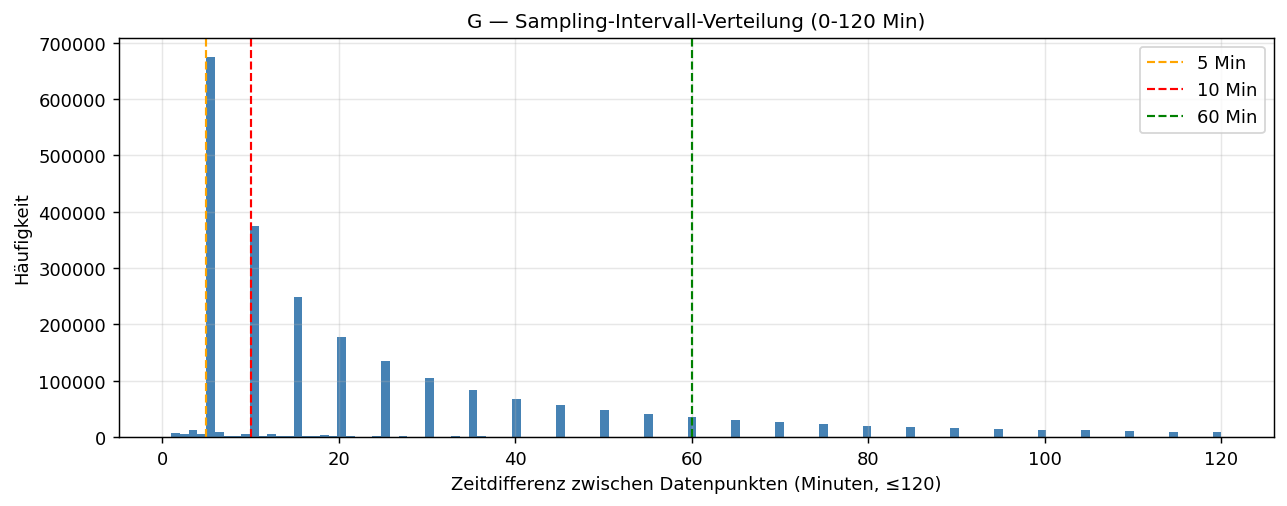

✅ Plot G1 gespeichert.


In [26]:
# ══════════════════════════════════════════════════════════════
# AUDIT-BLOCK G: Stündliche Datendichte & Sampling-Rate
# Fragestellung: Wie oft kommen Datenpunkte pro Station/Stunde?
# Unregelmäßiges Sampling → Aggregationsfehler?
# ══════════════════════════════════════════════════════════════
print('='*60)
print('BLOCK G: Sampling-Rate & Datendichte')
print('='*60)

# Zeitdifferenzen zwischen aufeinanderfolgenden Datenpunkten pro Station
demand_sorted = demand_real.sort_values(['station_id', 'timestamp'])
demand_sorted['time_diff_min'] = (
    demand_sorted.groupby('station_id')['timestamp']
    .diff()
    .dt.total_seconds() / 60
)

# Häufigste Sampling-Intervalle
time_diffs_nonzero = demand_sorted['time_diff_min'].dropna()
time_diffs_nonzero = time_diffs_nonzero[time_diffs_nonzero > 0]

print(f'Sampling-Intervalle (Minuten):')
print(time_diffs_nonzero.describe().to_string())
print(f'\nHäufigste Intervalle:')
print(time_diffs_nonzero.round(0).value_counts().head(15).to_string())

# Sehr kurze Intervalle (< 1 Min) → mögliche Duplikate
sub_minute = (time_diffs_nonzero < 1).sum()
print(f'\nZeitdifferenzen < 1 Minute: {sub_minute:,} ({sub_minute/len(time_diffs_nonzero)*100:.2f}%)')
print(f'→ Mögliche Duplikate oder sehr schnelle Ereignisse (z.B. Systemfehler).')

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
time_diffs_plot = time_diffs_nonzero[(time_diffs_nonzero > 0) & (time_diffs_nonzero <= 120)]
ax.hist(time_diffs_plot, bins=120, color='steelblue', edgecolor='none')
ax.set_xlabel('Zeitdifferenz zwischen Datenpunkten (Minuten, ≤120)')
ax.set_ylabel('Häufigkeit')
ax.set_title('G — Sampling-Intervall-Verteilung (0-120 Min)')
ax.axvline(5, color='orange', ls='--', lw=1.2, label='5 Min')
ax.axvline(10, color='red', ls='--', lw=1.2, label='10 Min')
ax.axvline(60, color='green', ls='--', lw=1.2, label='60 Min')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{AUDIT_OUTPUT}/G1_sampling_rate.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Plot G1 gespeichert.')

In [27]:
# ══════════════════════════════════════════════════════════════
# ZUSAMMENFASSUNG: Alle Audit-Befunde & Cleaning-Empfehlungen
# ══════════════════════════════════════════════════════════════
print('='*70)
print('AUDIT-ZUSAMMENFASSUNG & CLEANING-EMPFEHLUNGEN')
print('='*70)

findings = []

# Befunde aus Block A
if len(missing_days) > 0:
    findings.append(('KRITISCH', 'A', f'{len(missing_days)} Tage ohne Datensätze → Ausschließen aus Training/Test'))
if len(zero_days) > 0:
    findings.append(('KRITISCH', 'A', f'{len(zero_days)} Tage mit Demand=0 (Systemausfall?) → Untersuchen & flaggen'))
if len(low_days) > 0:
    findings.append(('WARNUNG', 'A', f'{len(low_days)} Tage unter P5-Schwelle → Möglicherweise partielle Systemausfälle'))

# Befunde aus Block B
if len(multi_id_locations) > 0:
    findings.append(('WARNUNG', 'B', f'{len(multi_id_locations)} Locations mit mehreren station_ids → ID-Wechsel möglich'))
if (station_gaps['max_gap_days'] > 90).sum() > 0:
    n = (station_gaps['max_gap_days'] > 90).sum()
    findings.append(('WARNUNG', 'B', f'{n} Stationen mit Datenlücke > 90 Tage → Lebenszyklus-Filter empfohlen'))
if (station_gaps['max_gap_days'] > 180).sum() > 0:
    n = (station_gaps['max_gap_days'] > 180).sum()
    findings.append(('KRITISCH', 'B', f'{n} Stationen mit Lücke > 180 Tage → Aus Experiment ausschließen'))

# Befunde aus Block C
high_zero_stations = (zero_rate['zero_rate'] > 0.95).sum()
if high_zero_stations > 0:
    findings.append(('WARNUNG', 'C', f'{high_zero_stations} Stationen mit >95% Zero-Rate → Sehr schwaches Signal'))

if len(conservative_zscore) > 0:
    findings.append(('HINWEIS', 'C', f'{len(conservative_zscore)} Stationen: z-Score könnte Poisson-Rauschen als Anomalie labeln'))

# Befunde aus Block D
if len(outside_bbox) > 0:
    findings.append(('KRITISCH', 'D', f'{len(outside_bbox)} Stationen außerhalb Mannheim-Bounding-Box → Geo-Check!'))
if len(no_geo) > 0:
    findings.append(('HINWEIS', 'D', f'{len(no_geo)} Stationen ohne Geo-Koordinaten'))

# Befunde aus Block G
if sub_minute > 0:
    findings.append(('HINWEIS', 'G', f'{sub_minute:,} Zeitdifferenzen < 1 Min → Prüfen auf Duplikate'))

# Ausgabe
severity_order = {'KRITISCH': 0, 'WARNUNG': 1, 'HINWEIS': 2}
findings.sort(key=lambda x: severity_order.get(x[0], 3))

print(f'\n{"Severity":<10} {"Block":<6} Befund')
print('-'*70)
for severity, block, desc in findings:
    icon = {'KRITISCH': '🔴', 'WARNUNG': '🟡', 'HINWEIS': '🔵'}[severity]
    print(f'{icon} {severity:<10} [{block}]   {desc}')

print('\n' + '='*70)
print('KONKRETE CLEANING-MASSNAHMEN (Priorität 1-3)')
print('='*70)

print('''
PRIO 1 — Systemausfälle markieren & herausfiltern:
  → Tage mit city-level demand < P1 (oder = 0) als SYSTEM_OUTAGE flaggen
  → Diese Stunden aus Training UND Test herausnehmen
  → Begründung: Systemausfälle sind keine Demand-Anomalien

PRIO 1 — Stationslebenszyklus respektieren:
  → Für jede Station nur Zeitraum [first_active + 7 Tage, last_active - 7 Tage] nutzen
  → Erste/letzte 7 Tage sind oft technische Einführung / Rückbau → kein normales Muster
  → Stationen mit Lücke > 90 Tage: Entweder aufteilen (2 Episoden) oder ausschließen

PRIO 2 — Extreme Demand-Werte prüfen:
  → Stunden > 99.9-Perzentile manuell prüfen (sind das Events? Datenfehler?)
  → Stationen mit Lends/Returns-Ratio > 5 prüfen (plausibel für BSS?)

PRIO 2 — Stationsfilter schärfen:
  → Station-Lebensspanne < 30 Tage: Aus Experiment ausschließen
  → Zero-Rate > 95%: Aus Experiment ausschließen (zu wenig Signal)

PRIO 3 — Labeling-Alternative testen:
  → Poisson-ppf(0.9987) als Alternative zu z-Score=3 implementieren
  → Vergleich: Wie viele zusätzliche/weniger Labels entstehen?
  → Besonders relevant für Stationen mit hist_mean < 3
''')

print('='*70)
print('✅ Audit abgeschlossen. Plots gespeichert in:', AUDIT_OUTPUT)
print('='*70)

AUDIT-ZUSAMMENFASSUNG & CLEANING-EMPFEHLUNGEN

Severity   Block  Befund
----------------------------------------------------------------------
🔴 KRITISCH   [A]   1 Tage ohne Datensätze → Ausschließen aus Training/Test
🔴 KRITISCH   [B]   2 Stationen mit Lücke > 180 Tage → Aus Experiment ausschließen
🟡 WARNUNG    [A]   52 Tage unter P5-Schwelle → Möglicherweise partielle Systemausfälle
🟡 WARNUNG    [B]   8 Locations mit mehreren station_ids → ID-Wechsel möglich
🟡 WARNUNG    [B]   5 Stationen mit Datenlücke > 90 Tage → Lebenszyklus-Filter empfohlen
🟡 WARNUNG    [C]   29 Stationen mit >95% Zero-Rate → Sehr schwaches Signal

KONKRETE CLEANING-MASSNAHMEN (Priorität 1-3)

PRIO 1 — Systemausfälle markieren & herausfiltern:
  → Tage mit city-level demand < P1 (oder = 0) als SYSTEM_OUTAGE flaggen
  → Diese Stunden aus Training UND Test herausnehmen
  → Begründung: Systemausfälle sind keine Demand-Anomalien

PRIO 1 — Stationslebenszyklus respektieren:
  → Für jede Station nur Zeitraum [first_acti

In [28]:
# ── Optionaler Export der Audit-Ergebnisse als CSV ──
# Nützlich für Dokumentation in der BA

summary_df = pd.DataFrame(findings, columns=['Severity', 'Block', 'Beschreibung'])
summary_df.to_csv(f'{AUDIT_OUTPUT}/audit_summary.csv', index=False)

station_lifecycle.to_csv(f'{AUDIT_OUTPUT}/station_lifecycle.csv', index=False)
station_gaps.to_csv(f'{AUDIT_OUTPUT}/station_gaps.csv', index=False)
daily_city.to_csv(f'{AUDIT_OUTPUT}/daily_city_demand.csv', index=False)

print('✅ Audit-CSV-Dateien gespeichert:')
print(f'  {AUDIT_OUTPUT}/audit_summary.csv')
print(f'  {AUDIT_OUTPUT}/station_lifecycle.csv')
print(f'  {AUDIT_OUTPUT}/station_gaps.csv')
print(f'  {AUDIT_OUTPUT}/daily_city_demand.csv')

✅ Audit-CSV-Dateien gespeichert:
  /content/data/audit_plots/audit_summary.csv
  /content/data/audit_plots/station_lifecycle.csv
  /content/data/audit_plots/station_gaps.csv
  /content/data/audit_plots/daily_city_demand.csv
